In [ ]:
import os
from google.colab import drive

# Define the base path for mounting Google Drive
BASE_DRIVE_PATH = '/content'
drive.mount(os.path.join(BASE_DRIVE_PATH, 'drive'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Define the base path for saving models and experiment states in Google Drive
BASE_DRIVE_PATH = os.path.join(BASE_DRIVE_PATH, 'drive/MyDrive/NEW')

# Create the base directory if it doesn't exist
os.makedirs(BASE_DRIVE_PATH, exist_ok=True)
os.makedirs(os.path.join(BASE_DRIVE_PATH, 'experiment_states'), exist_ok=True)

print(f"Base path for saving models set to: {BASE_DRIVE_PATH}")

Base path for saving models set to: /content/drive/MyDrive/NEW


In [ ]:
!pip install nlp-id

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mellychandrawardani/rumahsakit/main/ulasan_rs.xlsx"
df = pd.read_excel(url)
display(df)

,Name,Date,Review
0,Nashrullah,2 minggu lalu,"Walau jauh dr lamongan, setiap anak² sakit, Rs..."
1,Rafael Mecca Prasetya,4 minggu lalu,"Pelayanan fisioterapi sangat baik, bagus dan c..."
2,Maria Amelia,3 minggu lalu,Untuk pertama kalinya masuk RS dan dpt pengala...
3,maisie lucida,2 bulan lalu,Ini ke-3x nya anak saya harus dirawat di RS Mi...
4,Aisyah Assafira,sebulan lalu,RS pilihan keluarga dan selalu dengan pelayana...
...,...,...,...
2495,natassya yudhawirawan,setahun lalu,Ruang inap Flamboyan nyaman
2496,Ahmad Rofi,setahun lalu,Kualitas layanan Mitra memuaskan
2497,Desfirea K,setahun lalu,Petugas administrasi Darmo sigap
2498,yoga prasetyo,setahun lalu,Area parkir Satelit luas


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Jumlah data mentah asli: {len(df)} baris")
print(f"Jumlah data latih: {len(X_train)} baris")
print(f"Jumlah data uji: {len(X_test)} baris")


Jumlah data mentah asli: 2500 baris
Jumlah data latih: 2000 baris
Jumlah data uji: 500 baris


In [ ]:
import os
import pandas as pd

# Define PREPROCESSED_DATA_DIR before it's used
# BASE_DRIVE_PATH is expected to be defined in a previous cell
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')

# Ensure the preprocessed data directory exists
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)

# Save X_train to X_Train.xlsx
X_train.to_excel(os.path.join(PREPROCESSED_DATA_DIR, 'X_Train.xlsx'), index=False)
print(f'X_train saved to {os.path.join(PREPROCESSED_DATA_DIR, "X_Train.xlsx")}')

# Save X_test to X_Test.xlsx
X_test.to_excel(os.path.join(PREPROCESSED_DATA_DIR, 'X_Test.xlsx'), index=False)
print(f'X_test saved to {os.path.join(PREPROCESSED_DATA_DIR, "X_Test.xlsx")}')

X_train saved to /content/drive/MyDrive/NEW/preprocessed_data/X_Train.xlsx
X_test saved to /content/drive/MyDrive/NEW/preprocessed_data/X_Test.xlsx


In [ ]:
import pandas as pd
import re
import os # Ensure os is imported

# === LOAD KAMUS SLANG → FORMAL ===
kamus_url = "https://raw.githubusercontent.com/mellychandrawardani/rumahsakit/main/colloquial-indonesian-lexicon1.csv"

try:
    kamus_df = pd.read_csv(kamus_url, encoding="utf-8")
except UnicodeDecodeError:
    kamus_df = pd.read_csv(kamus_url, encoding="ISO-8859-1")
except Exception as e:
    print(f"An unexpected error occurred while loading the dictionary: {e}")
    kamus_df = pd.read_csv(kamus_url, delimiter=';', encoding="ISO-8859-1")

kamus_df.columns = [c.lower().strip() for c in kamus_df.columns]
slang_dict = dict(zip(kamus_df['slang'], kamus_df['formal']))

# === FUNGSI FORMALISASI ===
def formalisasi(teks):
    teks = teks.replace('\n', ' ')
    teks = re.sub(r'\b([a-z]+)\s*[\d²]+\b', r'\1-\1', teks)
    kata = teks.split()
    kata = [slang_dict.get(k, k) for k in kata]

    return " ".join(kata)

X_train['Normalized Review'] = X_train['Review'].apply(formalisasi)

print("First 5 rows of X_train with updated normalized reviews:")
display(X_train[['Review', 'Normalized Review']].head())

# Create a subdirectory for preprocessed data in Google Drive
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)

X_train.to_excel(os.path.join(PREPROCESSED_DATA_DIR, 'X_train_normalized.xlsx'), index=False)
print('X_train with normalized reviews saved to drive in X_train_normalized.xlsx')

First 5 rows of X_train with updated normalized reviews:


,Review,Normalized Review
2055,Ruang flamboyan rs mitra keluarga darmo sateli...,Ruang flamboyan rumah sakit mitra keluarga dar...
1961,nilai plusnya\n-dekat dr rumah\n-obat yg diber...,nilai plusnya -dekat dari rumah -obat yang dib...
1864,Pelayanan cukup cepat dan simpatik... sesuai d...,Pelayanan cukup cepat dan simpatik... sesuai d...
2326,Pelayanan baik memuaskan,Pelayanan baik memuaskan
461,Terima kasih atas pelayanannya selama saya mel...,Terima kasih atas pelayanannya selama saya mel...


X_train with normalized reviews saved to drive in X_train_normalized.xlsx


In [ ]:
!pip install nlp-id==0.1.6 -q
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 26.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 55.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for scikit-learn
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (scikit-learn)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from nlp_id.postag import PosTag

# Memuat data training yang sudah diformalisasi
df = pd.read_excel(os.path.join(PREPROCESSED_DATA_DIR, 'X_train_normalized.xlsx'))
postagger = PosTag()

def pos_tag_nlp_id(teks):
    try:
        hasil = postagger.get_pos_tag(str(teks))
        if hasil:
            return " ".join([f"{kata}/{tag}" for kata, tag in hasil])
        else:
            return ""
    except Exception as e:
        print(f"⚠️ Error di teks: {teks} -> {e}")
        return ""
tqdm.pandas()
df['POS_Tag'] = df['Normalized Review'].progress_apply(pos_tag_nlp_id)

from IPython.display import display
print("\n✅ POS Tagging selesai! Contoh hasil:")
display(df[['Normalized Review', 'POS_Tag']].head(5))

# Menyimpan hasil POS Tagging untuk data training
df.to_excel(os.path.join(BASE_DRIVE_PATH, 'Dataset_RS_POSTag.xlsx'), index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


postagger_v10.pkl:   0%|          | 0.00/282M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DictVectorizer from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.1 when using version 1.8.0. This might lead to b


✅ POS Tagging selesai! Contoh hasil:


,Normalized Review,POS_Tag
0,Ruang flamboyan rumah sakit mitra keluarga dar...,Ruang/NN flamboyan/NN rumah/NN sakit/NN mitra/...
1,nilai plusnya -dekat dari rumah -obat yang dib...,nilai/NN plus/JJ nya/PR -/SYM dekat/JJ dari/IN...
2,Pelayanan cukup cepat dan simpatik... sesuai d...,Pelayanan/NN cukup/ADV cepat/JJ dan/CC simpati...
3,Pelayanan baik memuaskan,Pelayanan/NN baik/JJ memuaskan/VB
4,Terima kasih atas pelayanannya selama saya mel...,Terima/JJ kasih/NN atas/IN pelayanan/NN nya/PR...


In [ ]:
import re

PUNCTUATION_SEPARATORS = ['.', ',', '!', '?', ';', ':', '...', '!!', '??']

def split_review_into_segments(review_text):
    if not isinstance(review_text, str) or not review_text.strip():
        return []
    regex_pattern = '|'.join(map(re.escape, PUNCTUATION_SEPARATORS))
    segmen = re.split(regex_pattern, review_text)
    return [s.strip() for s in segmen if s.strip()]

# Apply the segmentation function to create the 'Segments' column
df['Segments'] = df['Normalized Review'].apply(split_review_into_segments)

segment_rows = []

for idx, row in df.iterrows():

    for seg in row['Segments']:

        segment_rows.append({
            "Review": row['Normalized Review'],
            "Segment": seg
        })

df_segment = pd.DataFrame(segment_rows)

display(df_segment.head(50))

df_segment.to_excel(
    os.path.join(BASE_DRIVE_PATH, "hasil_segmentasi.xlsx"),
    index=False
)

,Review,Segment
0,Ruang flamboyan rumah sakit mitra keluarga dar...,Ruang flamboyan rumah sakit mitra keluarga dar...
1,Ruang flamboyan rumah sakit mitra keluarga dar...,walau kamar penuh kami tetap ditampung untuk b...
2,Ruang flamboyan rumah sakit mitra keluarga dar...,Para perawat sangat ramah dan baik
3,nilai plusnya -dekat dari rumah -obat yang dib...,nilai plusnya -dekat dari rumah -obat yang dib...
4,Pelayanan cukup cepat dan simpatik... sesuai d...,Pelayanan cukup cepat dan simpatik
5,Pelayanan cukup cepat dan simpatik... sesuai d...,sesuai dengan tarafnya
6,Pelayanan cukup cepat dan simpatik... sesuai d...,tarifnya juga termasuk premium
7,Pelayanan baik memuaskan,Pelayanan baik memuaskan
8,Terima kasih atas pelayanannya selama saya mel...,Terima kasih atas pelayanannya selama saya mel...
9,Terima kasih atas pelayanannya selama saya mel...,Dokter


In [ ]:
def parse_pos_tag_field(pos_tag_str):
    if not isinstance(pos_tag_str, str) or not pos_tag_str:
        return []
    parsed_tags = []
    for item in pos_tag_str.split():
        parts = item.rsplit('/', 1) # Split only on the last '/' in case words contain '/'
        if len(parts) == 2:
            parsed_tags.append((parts[0], parts[1]))
        else:
            # Handle cases where a word might not have a tag or is malformed
            parsed_tags.append((parts[0], 'UNKNOWN'))
    return parsed_tags

def run_single_rule(
    df,
    rule_num,
    pattern,
    is_cc_rule=False
):

    hasil = []

    for idx, row in df.iterrows():

        segments = row['Segments']
        words_tags_overall_review = parse_pos_tag_field(
            row['POS_Tag']
        )

        for seg in segments:

            seg_words_list_lower = [
                w.lower()
                for w in seg.split()
            ]

            kata_kal_for_segment = []

            temp_seg_words_list_lower = list(
                seg_words_list_lower
            )

            for word_full, tag_full in words_tags_overall_review:

                if word_full.lower() in temp_seg_words_list_lower:

                    kata_kal_for_segment.append(
                        (word_full, tag_full)
                    )

                    temp_seg_words_list_lower.remove(
                        word_full.lower()
                    )

                if not temp_seg_words_list_lower:
                    break

            kata_kal = kata_kal_for_segment

            if not kata_kal:
                continue

            tags = [t for _, t in kata_kal]
            words = [w for w, _ in kata_kal]

            plen = len(pattern)

            for i in range(len(tags) - plen + 1):

                if tags[i:i+plen] == pattern:

                    if is_cc_rule:
                        outputs = []
                        cc_global_idx = -1
                        # Find the global index of 'CC' within the matched pattern
                        for k_offset in range(plen):
                            if kata_kal[i + k_offset][1] == 'CC':
                                cc_global_idx = i + k_offset
                                break

                        if cc_global_idx == -1: # This should not happen if the pattern contains 'CC'
                            continue

                        # --- Rule-specific logic for coordinated opinions ---
                        if rule_num == 31: # NN + NN + CC + NN + ADV + JJ
                            # Example: "Pelayanan perawat dan dokter sangat ramah" -> "Pelayanan perawat sangat ramah", "Pelayanan dokter sangat ramah"

                            # Common prefix is the first NN in the matched pattern
                            common_prefix_words = [words[i]]

                            # Extract coordinated nouns and the adjective phrase
                            nn1_word = words[i+1] # The first NN after the common prefix
                            nn2_word = words[cc_global_idx + 1] # The NN after CC
                            # The adjective phrase includes ADV and JJ
                            adj_phrase_words = words[cc_global_idx + 2 : i + plen]

                            # Output 1: Common Prefix + NN1 + Adjective Phrase
                            opinion1_parts = common_prefix_words + [nn1_word] + adj_phrase_words
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: Common Prefix + NN2 + Adjective Phrase
                            opinion2_parts = common_prefix_words + [nn2_word] + adj_phrase_words
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 32: # NN + NN + JJ + CC + JJ
                            # Example: "Pelayanan administrasi cepat dan ramah" -> "Pelayanan administrasi cepat", "Pelayanan administrasi ramah"
                            # Common prefix consists of the first two NNs within the matched pattern
                            common_prefix_words = words[i : i+2]

                            # Output 1: Common Prefix + JJ1
                            opinion1_parts = common_prefix_words + [words[i+2]] # words[i+2] is the first JJ
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: Common Prefix + JJ2
                            opinion2_parts = common_prefix_words + [words[cc_global_idx + 1]] # words[cc_global_idx + 1] is the second JJ
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 33: # NN + NN + JJ + CC + JJ
                            # Example: "Ruang tunggu nyaman dan bersih" -> "Ruang tunggu nyaman", "Ruang tunggu bersih"
                            # Common prefix consists of the first two NNs within the matched pattern
                            common_prefix_words = words[i : i+2]

                            # Output 1: Common Prefix + JJ1
                            opinion1_parts = common_prefix_words + [words[i+2]] # words[i+2] is the first JJ
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: Common Prefix + JJ2
                            opinion2_parts = common_prefix_words + [words[cc_global_idx + 1]] # words[cc_global_idx + 1] is the second JJ
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 34: # NN + CC + NN + JJ
                            # Example: "Dokter dan perawat ramah kepada pasien" -> "Perawat ramah", "Dokter ramah"
                            nn1_word = words[i]
                            nn2_word = words[cc_global_idx + 1]
                            adj_word = words[i + plen - 1] # JJ is the last word in the pattern

                            # Output 1: NN2 + Adjective
                            opinion1_parts = [nn2_word, adj_word]
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: NN1 + Adjective
                            opinion2_parts = [nn1_word, adj_word]
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 35: # NN + CC + NN + VB + NN
                            # Example: "Dokter dan perawat membantu pasien dengan cepat" -> "Perawat membantu pasien", "Dokter membantu pasien"
                            nn1_word = words[i]
                            nn2_word = words[cc_global_idx + 1]
                            vb_word = words[i + plen - 2] # VB is the second to last in the pattern
                            obj_word = words[i + plen - 1] # NN (pasien) is the last in the pattern

                            # Output 1: NN2 + VB + NN (object)
                            opinion1_parts = [nn2_word, vb_word, obj_word]
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: NN1 + VB + NN (object)
                            opinion2_parts = [nn1_word, vb_word, obj_word]
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 36: # NN + NN + JJ + CC + JJ
                            # Example: "Pelayanan administrasi rumah sakit cepat dan ramah selama proses pendaftaran" -> "Pelayanan administrasi rumah sakit cepat", "Pelayanan administrasi rumah sakit ramah"
                            # Common prefix consists of the first two NNs within the matched pattern
                            common_prefix_words = words[i : i+2]

                            # Output 1: Common Prefix + JJ1
                            opinion1_parts = common_prefix_words + [words[i+2]] # words[i+2] is the first JJ
                            opinion1 = " ".join(opinion1_parts).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: Common Prefix + JJ2
                            opinion2_parts = common_prefix_words + [words[cc_global_idx + 1]] # words[cc_global_idx + 1] is the second JJ
                            opinion2 = " ".join(opinion2_parts).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        elif rule_num == 37: # NN + JJ + CC + NN + JJ
                            # Example: "Pelayanan cepat dan fasilitas lengkap" -> "Pelayanan lengkap", "Fasilitas lengkap"
                            # This rule's logic already matches the user's desired output for the given example. No changes needed.
                            # Output 1: NN1 + JJ2 (first word of pattern + last word of pattern)
                            opinion1_words = [kata_kal[i][0], kata_kal[i + plen - 1][0]]
                            opinion1 = " ".join(opinion1_words).strip()
                            if opinion1 and len(opinion1.split()) > 1:
                                outputs.append(opinion1)

                            # Output 2: NN2 + JJ2 (word directly after CC + last word of pattern)
                            opinion2_words = [kata_kal[cc_global_idx + 1][0], kata_kal[i + plen - 1][0]]
                            opinion2 = " ".join(opinion2_words).strip()
                            if opinion2 and len(opinion2.split()) > 1 and opinion2 not in outputs:
                                outputs.append(opinion2)

                        # Add extracted opinions to results
                        for op in outputs:
                            op = op.strip()
                            if op:
                                hasil.append({
                                    "Review": row["Normalized Review"],
                                    "Segment": seg,
                                    "Rule": f"Rule {rule_num}",
                                    "Opinion": op
                                })

                    else:

                        opinion = " ".join(
                            words[i:i+plen]
                        )

                        hasil.append({
                            "Review": row["Normalized Review"],
                            "Segment": seg,
                            "Rule": f"Rule {rule_num}",
                            "Opinion": opinion
                        })

    hasil_df = pd.DataFrame(hasil)

    if not hasil_df.empty:

        hasil_df = hasil_df.drop_duplicates(
            subset=[
                "Review",
                "Opinion",
                "Rule"
            ]
        )

    print(f"Rule {rule_num}")
    print(f"Jumlah hasil : {len(hasil_df)}")

    display(hasil_df.head(20))

    return hasil_df

In [ ]:
df_rule1 = run_single_rule(
   df,
    1,
    ['NN', 'JJ']
)

Rule 1
Jumlah hasil : 1944


,Review,Segment,Rule,Opinion
0,Ruang flamboyan rumah sakit mitra keluarga dar...,walau kamar penuh kami tetap ditampung untuk b...,Rule 1,kamar penuh
1,Ruang flamboyan rumah sakit mitra keluarga dar...,Para perawat sangat ramah dan baik,Rule 1,perawat ramah
2,nilai plusnya -dekat dari rumah -obat yang dib...,nilai plusnya -dekat dari rumah -obat yang dib...,Rule 1,kebetulan cocok
3,Pelayanan baik memuaskan,Pelayanan baik memuaskan,Rule 1,Pelayanan baik
4,"Dirawat inap di kamar Flamboyan, setelah opera...",Thankyouu untuk semua tenaga medis yang ada,Rule 1,tenaga medis
5,"permisi kenapa ya pasien JKN hari ini , hari t...",hari terakhir sebelum JKN dicabut kenapa diper...,Rule 1,hari terakhir
6,"RS yang nyaman, pelayan oke. Suster lantai-lan...",pelayan oke,Rule 1,pelayan oke
7,"RS yang nyaman, pelayan oke. Suster lantai-lan...",Suster lantai-lantai ruang anak flamboyan baik...,Rule 1,flamboyan baik
8,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 1,Pelayanan baik
9,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 1,luar biasa


In [ ]:
df_rule2 = run_single_rule(
   df,
    2,
    ['NN', 'VB', 'JJ']
)

Rule 2
Jumlah hasil : 111


,Review,Segment,Rule,Opinion
0,Pelayanan baik cepat tanggap luar biasa baik. ...,Sediakan ruang tunggu khusus untuk keluarga pa...,Rule 2,ruang tunggu khusus
1,"Pelayanan bagus, pegawai ramah, RS bersih. Pas...",Pasien jadi nyaman 👍,Rule 2,Pasien jadi nyaman
2,"Pelayanan memuaskan, dokter dan semua paramedi...",😍 Menu makanan bervariasi dan sesuai selera,Rule 2,makanan bervariasi sesuai
3,Saya kecewa dengan pelayanan staff di persada ...,staff ternyata salah memasukkan data,Rule 2,staff ternyata salah
4,Dari hamil sampai lahiran full semua ke persad...,Mulai dari awal pendaftaran punya baru petugas...,Rule 2,pendaftaran punya baru
5,Pengalaman saya selama persalinan pada bulan o...,sehingga membuat pengalaman perawatan menjadi ...,Rule 2,perawatan menjadi jauh
6,Pelayanannya sangat responsif dan profesional....,Suasana dalam kamar pasien juga sangat kondusi...,Rule 2,pendamping merasa aman
7,Pelayanan bagus ramah anak terima BPJS juga ti...,Pak Wiyono dan karyawan bagian BPJS juga baik ...,Rule 2,bagian terimakasih banyak
8,Pelayanan bagus ramah anak terima BPJS juga ti...,Foto makanan lupa semua enak baik pokoknya,Rule 2,Foto lupa enak
9,Penanganan di IGD fast respon dan tanggap seka...,Waktu Mami saya rawat inap pun bener-bener dip...,Rule 2,dokter bener-bener enak


In [ ]:
df_rule3 = run_single_rule(
   df,
    3,
    ['NN', 'ADV', 'JJ']
)

Rule 3
Jumlah hasil : 397


,Review,Segment,Rule,Opinion
0,Ruang flamboyan rumah sakit mitra keluarga dar...,Ruang flamboyan rumah sakit mitra keluarga dar...,Rule 3,pelayanan sangat baik
1,Pelayanan cukup cepat dan simpatik... sesuai d...,Pelayanan cukup cepat dan simpatik,Rule 3,Pelayanan cukup cepat
2,Saya sangat senang dapat konsultasi dengan dok...,Pelayanan juga cepat dan tidak ribet sama sekali,Rule 3,Pelayanan juga cepat
3,"Dokter ,suster serta karyawan semuanya baik...",suster serta karyawan semuanya baik,Rule 3,karyawan semuanya baik
4,Pelayanan administrasi sangat baik dan fast re...,Pelayanan administrasi sangat baik dan fast re...,Rule 3,administrasi sangat baik
5,"Suster Vita,suster disma,suster angel,dan selu...",dan seluruh perawat safir sangat sabar,Rule 3,safir sangat sabar
6,Pelayanan di farmasi sangat lama sekali Pegawa...,Pelayanan di farmasi sangat lama sekali Pegawa...,Rule 3,farmasi sangat lama
7,Pelayanan dari semua nakes sangat baik dan ram...,Pelayanan dari semua nakes sangat baik dan ramah,Rule 3,nakes sangat baik
8,Pelayanan dari semua nakes sangat baik dan ram...,Ruang kamar juga bersih dan sangat nyaman bagi...,Rule 3,kamar juga bersih
9,"Perawatan dan pelayanan RS. Phc sangat baik, d...",Phc sangat baik,Rule 3,Phc sangat baik


In [ ]:
df_rule4 = run_single_rule(
   df,
    4,
    ['NN', 'PR', 'JJ']
)

Rule 4
Jumlah hasil : 270


,Review,Segment,Rule,Opinion
0,Selalu suka mengantar anak berobat kesini. RS ...,RS dengan view taman yang cantik memberikan ke...,Rule 4,taman yang cantik
1,Pelayanan yang optimal dan bersih . Dokter dan...,Pelayanan yang optimal dan bersih,Rule 4,Pelayanan yang optimal
2,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 4,suami saya langsung
3,"Rumah sakit nya bersih, pelayanan nya ramah da...",Rumah sakit nya bersih,Rule 4,sakit nya bersih
4,"Rs yang nyaman, selalu langganan disini. Pelay...",Rs yang nyaman,Rule 4,Rs yang nyaman
5,"Rumah sakit yang bagus, menerapkan standard ya...",Rumah sakit yang bagus,Rule 4,sakit yang bagus
6,"Rumah sakit yang bersih, pelayanan yang baik, ...",Rumah sakit yang bersih,Rule 4,sakit yang bersih
7,Dlu waktu masih melayani BPJS walaupun menggun...,dg fasilitas rumah sakit yang bagus,Rule 4,sakit yang bagus
8,"Pelayanan sangat memuaskan , tempatnya bagus c...",didukung dokter-dokter dan perawat nya yang sa...,Rule 4,perawat yang ramah
9,"RS sakit dengan pelayanan yang super baik,cepa...",RS sakit dengan pelayanan yang super baik,Rule 4,pelayanan yang super


In [ ]:
df_rule5 = run_single_rule(
   df,
    5,
    ['NN', 'PR', 'VB']
)

Rule 5
Jumlah hasil : 256


,Review,Segment,Rule,Opinion
0,nilai plusnya -dekat dari rumah -obat yang dib...,nilai plusnya -dekat dari rumah -obat yang dib...,Rule 5,rumah yang diberikan
1,"Pelayanan di IGD kurang, 1, ada salah Satu per...",ada salah Satu perawat perempuan yang tidak be...,Rule 5,pasien yang ganti
2,Pelayanan baik cepat tanggap luar biasa baik. ...,Sediakan ruang tunggu khusus untuk keluarga pa...,Rule 5,pasien yang masuk
3,Urusan menjenguk sodara opname saja ribet bang...,harus-harus orang yang naik gantian,Rule 5,orang yang naik
4,Pelayanan administrasi sangat baik dan fast re...,Pelayanan administrasi sangat baik dan fast re...,Rule 5,perawat yang memberikan
5,Pelayanan administrasi sangat baik dan fast re...,terima kasih atas pelayanan terbaik yang sudah...,Rule 5,pasien yang terima
6,Bangsal flamboyan yang melayani anak saya keti...,Bangsal flamboyan yang melayani anak saya keti...,Rule 5,flamboyan yang melayani
7,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 5,sakit ini terima
8,"perawat di ruang bugenvile baik baik, pelayana...",pelayanan yang di berikan sangat bagus sekali ...,Rule 5,pelayanan yang berikan
9,"Pelayanan, fasilitas terbaik Dengan dokter dan...",fasilitas terbaik Dengan dokter dan perawat ya...,Rule 5,perawat yang berpengalaman


In [ ]:
df_rule6 = run_single_rule(
   df,
    6,
    ['NN', 'DT', 'JJ']
)

Rule 6
Jumlah hasil : 46


,Review,Segment,Rule,Opinion
0,"Dirawat inap di kamar Flamboyan, setelah opera...",makanannya enak-enak dan membuat recovery sela...,Rule 6,rawat ini lumayan
1,"Rs yang nyaman, selalu langganan disini. Pelay...",Pelayanan nya ramah susternya baik-baik,Rule 6,Pelayanan nya ramah
2,Terima kasih para medis (para dokter dan peraw...,Terima kasih para medis (para dokter dan peraw...,Rule 6,kasih para medis
3,Pelayanan bagus ramah anak terima BPJS juga ti...,Pelayanan bagus ramah anak terima BPJS juga ti...,Rule 6,fasilitas semua baik
4,Petugas nya baik dan ada yang cantik menanyaka...,Petugas nya baik dan ada yang cantik menanyaka...,Rule 6,Petugas nya baik
5,"Terimakasih persada, dokter perawat pendaftara...",dokter perawat pendaftaran IGD dan pendaftaran...,Rule 6,kontrol semua baik
6,Sudah 2 kali berobat di Rs Mitra Keluarga. Pel...,Makanan nya cocok,Rule 6,Makanan nya cocok
7,Pelayanan nya baik..tmpt nya bersih perawat ny...,Pelayanan nya baik,Rule 6,Pelayanan nya baik
8,"Mulai dari security , adm cetak SEP , Bpk Wiyo...",Bpk Wiyono dan paramrdis lainnya semua ramah d...,Rule 6,paramrdis semua ramah
9,Pelayannya bagus dan saya menggunakan bpjs tap...,Perawat semua sangat ramah walau bpjs,Rule 6,Perawat semua ramah


In [ ]:
df_rule7 = run_single_rule(
df,
7,
['NN', 'NN', 'VB']
)

Rule 7
Jumlah hasil : 276


,Review,Segment,Rule,Opinion
0,Pelayanan baik cepat tanggap luar biasa baik. ...,Apalagi dokter jantung menjelaskan dengan deta...,Rule 7,dokter jantung menjelaskan
1,Rumah sakit phc memberikan kesehatan dan kesel...,Rumah sakit phc memberikan kesehatan dan kesel...,Rule 7,sakit phc memberikan
2,"Duh kah parkirnya perjam, kan siapa yang mau l...",padahal yang bikin lama kan administrasi keson...,Rule 7,administrasi kesono kesini
3,"Pelayanan memuaskan, dokter dan semua paramedi...",😍 Menu makanan bervariasi dan sesuai selera,Rule 7,Menu makanan bervariasi
4,Dari hamil sampai lahiran full semua ke persad...,Mulai dari awal pendaftaran punya baru petugas...,Rule 7,awal pendaftaran punya
5,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,Rule 7,sakit demam berdarah
6,"Dari segi kebersihan sangat memuaskan,. Pelaya...",Ketepatan waktu tunggu pun sangat memuaskan,Rule 7,Ketepatan waktu tunggu
7,Alhamdulilah Siloam hospital menjawab semua kg...,(k) bliau juga mmandu kami untuk memilih pemer...,Rule 7,sgera trdeteksi tertangani
8,Dlu waktu masih melayani BPJS walaupun menggun...,Dlu waktu masih melayani BPJS walaupun menggun...,Rule 7,prima indak dibeda2kan
9,Uda sering kesini tapi kenapa di jadwal doktwr...,Uda sering kesini tapi kenapa di jadwal doktwr...,Rule 7,jadwal doktwr tertulis


In [ ]:
df_rule8 = run_single_rule(
df,
8,
['NN', 'JJ', 'JJ']
)

Rule 8
Jumlah hasil : 153


,Review,Segment,Rule,Opinion
0,"RS yang nyaman, pelayan oke. Suster lantai-lan...",Suster lantai-lantai ruang anak flamboyan baik...,Rule 8,flamboyan baik semua👍
1,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 8,Pelayanan baik cepat
2,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 8,luar biasa baik
3,Selalu suka mengantar anak berobat kesini. RS ...,Ruang tunggu anaknya ada playgroundnya yang lu...,Rule 8,playgroundnya luas bersih
4,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 8,dokter baik ramah
5,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,Rule 8,kontrol pertama aman-aman
6,Rumah sakitnya bersih nyaman dan penanganan ce...,Rumah sakitnya bersih nyaman dan penanganan ce...,Rule 8,Rumah bersih nyaman
7,"Gedung nyaman, pelayanan bpjs ramah cepat nyam...",pelayanan bpjs ramah cepat nyaman,Rule 8,bpjs ramah cepat
8,"Pelayanan bagus, semua susternya baik dan rama...",tempat nyaman dan bersih,Rule 8,tempat nyaman bersih
9,Untuk pertama kesan saya di igd kurang nyaman ...,Untuk kamar ranap nya (kelas-kelas) baik bersi...,Rule 8,ranap baik bersih


In [ ]:
df_rule9 = run_single_rule(
df,
9,
['NN', 'NN', 'JJ']
)

Rule 9
Jumlah hasil : 458


,Review,Segment,Rule,Opinion
0,"RS yang nyaman, pelayan oke. Suster lantai-lan...",Suster lantai-lantai ruang anak flamboyan baik...,Rule 9,anak flamboyan baik
1,Saya sangat senang dapat konsultasi dengan dok...,Suster juga ramah dan mungkin sediakan air put...,Rule 9,sediakan air putih
2,salah satu rumah sakit terbaik di Surabaya unt...,salah satu rumah sakit terbaik di Surabaya unt...,Rule 9,rumah sakit terbaik
3,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 9,selesa dokter baik
4,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,Rule 9,jan-jan kontrol pertama
5,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,tgl-tgl sd-sd jan-jan saya opname dengan sakit...,Rule 9,feb-feb kontrol kedua
6,"Gedung nyaman, pelayanan bpjs ramah cepat nyam...",pelayanan bpjs ramah cepat nyaman,Rule 9,pelayanan bpjs ramah
7,"Rumah sakit nya bersih, pelayanan nya ramah da...",pelayanan nya ramah dan terdapat berbagai maca...,Rule 9,tenant makanan serasa
8,"Perawatan dan pelayanan RS. Phc sangat baik, d...",dokter dan perawat sangat ramah,Rule 9,dokter perawat ramah
9,Untuk pertama kesan saya di igd kurang nyaman ...,Untuk kamar ranap nya (kelas-kelas) baik bersi...,Rule 9,kamar ranap baik


In [ ]:
df_rule10 = run_single_rule(
df,
10,
['JJ', 'NN', 'PR']
)

Rule 10
Jumlah hasil : 47


,Review,Segment,Rule,Opinion
0,Untuk pertama kesan saya di igd kurang nyaman ...,Untuk pertama kesan saya di igd kurang nyaman ...,Rule 10,pertama kesan saya
1,Senang pelayanan nya sangat gercep dan ramah,Senang pelayanan nya sangat gercep dan ramah,Rule 10,Senang pelayanan nya
2,Saya sangat puas dengan pelayanan yang diberik...,* - Pelayanan yang ramah dan profesional - Dok...,Rule 10,aman perawatan yang
3,Sudah 5x periksa ke dokter gigi Sandra di RS P...,sabar ngerawat gigi saya,Rule 10,sabar ngerawat saya
4,Selamat pagi saya dari keluarga ibu maria meng...,Selamat pagi saya dari keluarga ibu maria meng...,Rule 10,Selamat pagi saya
5,Anak saya sekali dirawat diruang flamboyan per...,Anak saya sekali dirawat diruang flamboyan per...,Rule 10,sama anak saya
6,"Pelayanan yang sangat baik bintang-bintang, pe...",perawat2nya gercep dan ramah tidak ada yang ju...,Rule 10,ramah anak saya
7,bagus pelayanan nya bintang-bintang perawat pe...,bagus pelayanan nya bintang-bintang perawat pe...,Rule 10,bagus pelayanan nya
8,Saya pasien Rawat Inap kelas-kelas di Siloam H...,Terima kasih dengan pelayanan rawat inap yang ...,Rule 10,baik pelayanan yang
9,Tepatnya tgl-tgl.04.2024 saya mengantar bapak ...,yang membuat kami kecewa satpam yang saat itu ...,Rule 10,kecewa satpam yang


In [ ]:
df_rule11 = run_single_rule(
df,
11,
['NN', 'NEG', 'JJ']
)

Rule 11
Jumlah hasil : 29


,Review,Segment,Rule,Opinion
0,"Satpam bagian belakang tidak ramah, judes, jut...",Satpam bagian belakang tidak ramah,Rule 11,belakang tidak ramah
1,"Gedung nyaman, pelayanan bpjs ramah cepat nyam...",hanya saja ada pegawai di bagian resepsionis r...,Rule 11,pertanyaan tidak senyum
2,Pelayanan di farmasi sangat lama sekali Pegawa...,Pelayanan di farmasi sangat lama sekali Pegawa...,Rule 11,kedalam enggak jelas
3,perlu di evaluasi sistim pengambilan obatnya t...,andai kan dikirim obatnya ongkir jangan mahal-...,Rule 11,ongkir jangan mahal-mahal
4,Dari IGD disarankan rawat inap..cepat dapat ka...,kamar bersih walo tidak luas,Rule 11,kamar tidak bersih
5,Pengalaman ke-ke periksa di RS Persada dan ter...,Dulu setauku enggak serumit ini,Rule 11,Dulu enggak serumit
6,sudah booking via web namun infonya harus teta...,mending ke siloam adminnya aktif konfirmasi ke...,Rule 11,ratenya enggak jauh
7,"Untuk pelayanan persada hostipal malang, khusu...",khususnya satpam cukup ramah namun terkadang a...,Rule 11,rasa enggak nyaman
8,Administrasi antrian pasien tidak jelas antri ...,Administrasi antrian pasien tidak jelas antri ...,Rule 11,pasien tidak jelas
9,Pelayanan kesehatan Baik dan mahal 😁 Saya akan...,Jangan lah hal yang mudah di jadikan sulit,Rule 11,hal Jangan mudah


In [ ]:
df_rule12 = run_single_rule(
df,
12,
['NN', 'ADV', 'VB']
)

Rule 12
Jumlah hasil : 279


,Review,Segment,Rule,Opinion
0,"Pelayanan di IGD kurang, 1, ada salah Satu per...",ada salah Satu perawat perempuan yang tidak be...,Rule 12,pasien malah nyuruh
1,"Satpam bagian belakang tidak ramah, judes, jut...",jutek Tolong pihak manajemen bisa ditegur mela...,Rule 12,manajemen bisa ditegur
2,Pelayanan perawat nya sangat ramah dan memuask...,Pelayanan perawat nya sangat ramah dan memuask...,Rule 12,opname sangat memuaskan👍👍
3,"Pelayanan memuaskan, dokter dan semua paramedi...",Kebersihan kamar sangat diperhatikan,Rule 12,kamar sangat diperhatikan
4,26 July 2025 proses perawatan masih berjalan s...,26 July 2025 proses perawatan masih berjalan s...,Rule 12,perawatan masih berjalan
5,26 July 2025 proses perawatan masih berjalan s...,ini proses masih berjalan dengan baik,Rule 12,proses masih berjalan
6,"Trima kasih terhadap pelayanan dipersada, poly...",poly A sangat ramah-ramah kepada pasien dan se...,Rule 12,persada sangat mebantu
7,Pengalaman kontrol hamil sampai dengan melahir...,Pengalaman kontrol hamil sampai dengan melahir...,Rule 12,spog sangat memuaskan
8,Pelayanan kurang memuaskan Dijadwalkan cek Rad...,Pelayanan kurang memuaskan Dijadwalkan cek Rad...,Rule 12,Pelayanan kurang memuaskan
9,"Dari segi kebersihan sangat memuaskan,. Pelaya...",Dari segi kebersihan sangat memuaskan,Rule 12,kebersihan sangat memuaskan


In [ ]:
df_rule13 = run_single_rule(
df,
13,
['NN', 'JJ', 'ADV']
)

Rule 13
Jumlah hasil : 153


,Review,Segment,Rule,Opinion
0,Pelayanan baik cepat tanggap luar biasa baik. ...,selebihnya sangat luar biasa,Rule 13,luar biasa selebihnya
1,Saya sangat senang dapat konsultasi dengan dok...,Pelayanan juga cepat dan tidak ribet sama sekali,Rule 13,ribet sama sekali
2,kontrol dan lahiran rumah sakit mitra dengan d...,kontrol dan lahiran rumah sakit mitra dengan d...,Rule 13,sakit cepat banget
3,Pelayanan baik sekali di rumah sakit phc. 2 an...,Pelayanan baik sekali di rumah sakit phc,Rule 13,Pelayanan baik sekali
4,"Pelayanan bagus,perawat dan dokter jelas sekal...",perawat dan dokter jelas sekali kalo kasih pen...,Rule 13,dokter jelas sekali
5,Pelayanan bagus ramah anak terima BPJS juga ti...,Makanan variatif dapat minum air putih botol d...,Rule 13,Makanan variatif dapat
6,Rumah sakit yang bukan seperti rumah sakit. Ng...,Pendaftaran mudah bisa reservasi online by wa,Rule 13,Pendaftaran mudah bisa
7,saya baru mau dirujuk kesini tapi malah tidak ...,saya baru mau dirujuk kesini tapi malah tidak ...,Rule 13,keburu sekarat malah
8,3 hari yang lalu anak saya mrs disini. Alhamdu...,Terimakasih sharingnya sus,Rule 13,sus Terimakasih sharingnya
9,Rumah Sakit dengan pelayanan baik sangat memua...,Rumah Sakit dengan pelayanan baik sangat memua...,Rule 13,pelayanan baik sangat


In [ ]:
df_rule14 = run_single_rule(
df,
14,
['NN', 'VB', 'ADV', 'JJ']
)

Rule 14
Jumlah hasil : 29


,Review,Segment,Rule,Opinion
0,Semua ramah dan sangat membantu kecuali untuk ...,Semua ramah dan sangat membantu kecuali untuk ...,Rule 14,radiologi tolong lebih sabar
1,"Melayani dengan baik,,, disemua loket pelayana...",hanya waktu saja yang kita memang harus bersab...,Rule 14,jumlah dilayani sangat banyak
2,Rumah sakit berkualitas sangat baik dengan pel...,Rumah sakit berkualitas sangat baik dengan pel...,Rule 14,sakit berkualitas sangat baik
3,RS swasta yang bagus sekali di Malang. Pelayan...,Pelayanan kesehatan yang tersedia juga lengkap,Rule 14,kesehatan tersedia juga lengkap
4,"Selama kami di icu, perlengkapan alat disini s...",perlengkapan alat disini sangat baik dan bagus...,Rule 14,alat disini sangat baik
5,Salah satu Rumah Sakit di Surabaya dengan fasi...,khususnya pelayanan di Poli Spesialis Anak yan...,Rule 14,Dokter menangani sangat kooperatif
6,Proses dicounter terlalu lama. Proses pembayar...,Proses dicounter terlalu lama,Rule 14,Proses dicounter terlalu lama
7,Pelayanan yang samgat memuaskan dari makanan d...,kemarin sc eracs disini-disini benar” sangat m...,Rule 14,eracs disini-disini sangat minim
8,Pelayanan kesehatan Baik dan mahal 😁 Saya akan...,Untuk penanganan dokumen untuk pulang juga ter...,Rule 14,dokumen pulang terlalu lama
9,Fasilitas rumah sakit ini cukup lengkap. Terse...,walau beberapa peralatan tampak agak tua namun...,Rule 14,peralatan tampak agak tua


In [ ]:
df_rule15 = run_single_rule(
df,
15,
['NN', 'NN', 'ADV', 'VB']
)

Rule 15
Jumlah hasil : 84


,Review,Segment,Rule,Opinion
0,"Pelayanan di IGD kurang, 1, ada salah Satu per...",ada salah Satu perawat perempuan yang tidak be...,Rule 15,pampers pasien malah nyuruh
1,"Satpam bagian belakang tidak ramah, judes, jut...",jutek Tolong pihak manajemen bisa ditegur mela...,Rule 15,pihak manajemen bisa ditegur
2,Pelayanan perawat nya sangat ramah dan memuask...,Pelayanan perawat nya sangat ramah dan memuask...,Rule 15,kali opname sangat memuaskan👍👍
3,"Pelayanan memuaskan, dokter dan semua paramedi...",Kebersihan kamar sangat diperhatikan,Rule 15,Kebersihan kamar sangat diperhatikan
4,26 July 2025 proses perawatan masih berjalan s...,26 July 2025 proses perawatan masih berjalan s...,Rule 15,proses perawatan masih berjalan
5,"Dari segi kebersihan sangat memuaskan,. Pelaya...",Dari segi kebersihan sangat memuaskan,Rule 15,segi kebersihan sangat memuaskan
6,Dlu waktu masih melayani BPJS walaupun menggun...,Dlu waktu masih melayani BPJS walaupun menggun...,Rule 15,Dlu waktu masih melayani
7,Pelayanan laboratorium sangat memuaskan Pelaya...,Pelayanan laboratorium sangat memuaskan Pelaya...,Rule 15,Pelayanan laboratorium sangat memuaskan
8,Pelayanan untuk pemeriksaan laboratorium sanga...,Pelayanan untuk pemeriksaan laboratorium sanga...,Rule 15,pemeriksaan laboratorium sangat memuaskan
9,Alhamdulillaah senang dan puas dengan pelayana...,A dan teman-teman maternal sudah merawat kami ...,Rule 15,teman-teman maternal sudah merawat


In [ ]:
df_rule16 = run_single_rule(
df,
16,
['NN', 'NN', 'ADV', 'JJ']
)

Rule 16
Jumlah hasil : 112


,Review,Segment,Rule,Opinion
0,Ruang flamboyan rumah sakit mitra keluarga dar...,Ruang flamboyan rumah sakit mitra keluarga dar...,Rule 16,sukomanunggal pelayanan sangat baik
1,Pelayanan administrasi sangat baik dan fast re...,Pelayanan administrasi sangat baik dan fast re...,Rule 16,Pelayanan administrasi sangat baik
2,"Suster Vita,suster disma,suster angel,dan selu...",dan seluruh perawat safir sangat sabar,Rule 16,perawat safir sangat sabar
3,Pelayanan dari semua nakes sangat baik dan ram...,Ruang kamar juga bersih dan sangat nyaman bagi...,Rule 16,Ruang kamar juga bersih
4,"Pelayanan di bangsal anak sangat baik, pasien ...",Pelayanan di bangsal anak sangat baik,Rule 16,bangsal anak sangat baik
5,Masyaallah tabarakallah Pelayanannya sangat ra...,Masyaallah tabarakallah Pelayanannya sangat ramah,Rule 16,Masyaallah tabarakallah sangat ramah
6,kontrol dan lahiran rumah sakit mitra dengan d...,kamar waktu lahiran juga bagus bersih makanany...,Rule 16,kamar waktu juga bagus
7,"Pelayanan sangat memuaskan , tempatnya bagus c...",ruang rawat inapnya juga bersih banget,Rule 16,ruang rawat juga bersih
8,Pelayanan diRS Mitra Keluarga Satelit sangat m...,dokter menjelaskan hsl pemeriksaan juga sangat...,Rule 16,hsl pemeriksaan juga jelas
9,Pelayanannya sangat responsif dan profesional....,Suasana dalam kamar pasien juga sangat kondusi...,Rule 16,kamar pasien juga kondusif


In [ ]:
df_rule17 = run_single_rule(
df,
17,
['NN', 'NN', 'PR', 'JJ']
)

Rule 17
Jumlah hasil : 82


,Review,Segment,Rule,Opinion
0,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 17,pagi suami saya langsung
1,"Rumah sakit nya bersih, pelayanan nya ramah da...",Rumah sakit nya bersih,Rule 17,Rumah sakit nya bersih
2,"Rumah sakit yang bagus, menerapkan standard ya...",Rumah sakit yang bagus,Rule 17,Rumah sakit yang bagus
3,"Rumah sakit yang bersih, pelayanan yang baik, ...",Rumah sakit yang bersih,Rule 17,Rumah sakit yang bersih
4,Dlu waktu masih melayani BPJS walaupun menggun...,dg fasilitas rumah sakit yang bagus,Rule 17,rumah sakit yang bagus
5,Kamar dan RS nya bersih. Pelayanan perawat dan...,terutama bisa akses kamar-kamar anakku yang la...,Rule 17,akses kamar-kamar yang langsung
6,"Rumah sakit yang pelayanannya bagus sekali, mu...",Rumah sakit yang pelayanannya bagus sekali,Rule 17,Rumah sakit yang bagus
7,Rumah sakit yang bagus di Surabaya dengan dokt...,Rumah sakit yang bagus di Surabaya dengan dokt...,Rule 17,Rumah sakit yang bagus
8,"Berobat ke igd pelayanan nya cepat, tempat nya...",Berobat ke igd pelayanan nya cepat,Rule 17,igd pelayanan nya cepat
9,"Rumah sakit yang bagus, bersih dan servis exel...",Rumah sakit yang bagus,Rule 17,Rumah sakit yang bagus


In [ ]:
df_rule18 = run_single_rule(
df,
18,
['NN', 'NN', 'PR', 'VB']
)

Rule 18
Jumlah hasil : 67


,Review,Segment,Rule,Opinion
0,"Pelayanan di IGD kurang, 1, ada salah Satu per...",ada salah Satu perawat perempuan yang tidak be...,Rule 18,keluarga pasien yang ganti
1,Bangsal flamboyan yang melayani anak saya keti...,Bangsal flamboyan yang melayani anak saya keti...,Rule 18,Bangsal flamboyan yang melayani
2,Waktu saya mau dikirim ke rumah sakit Surabaya...,Waktu saya mau dikirim ke rumah sakit Surabaya...,Rule 18,rumah sakit ini terima
3,Obat anak saya tertinggal di Farmasi RS Persad...,Obat anak saya tertinggal di Farmasi RS Persada,Rule 18,Obat anak saya tertinggal
4,Terima kasih para medis (para dokter dan peraw...,ramah dan sangat friendly yang sudah membantu ...,Rule 18,Persiapan istri saya melahirkan
5,Pelayanan bagus ramah anak terima BPJS juga ti...,Bisa di jaga di sediakan tempat sofa bed untuk...,Rule 18,sofa bed yang jaga
6,Saya sangat puas dengan pelayanan yang diberik...,* - Pelayanan yang ramah dan profesional - Dok...,Rule 18,profesional Dokter yang berpengalaman
7,"Alhamdulillah, rumah sakit persada memang terb...",rumah sakit persada memang terbaik Dan juga da...,Rule 18,pengamanan barang yang tertinggal
8,"Melayani dengan baik,,, disemua loket pelayana...",dokter-dokter dan perawatan nya juga tanggap,Rule 18,dokter-dokter perawatan nya tanggap
9,Suami n teman-teman yang memberikan arahan ber...,Suami n teman-teman yang memberikan arahan ber...,Rule 18,n teman-teman yang memberikan


In [ ]:
df_rule19 = run_single_rule(
df,
19,
['NN', 'DT', 'ADV', 'VB']
)

Rule 19
Jumlah hasil : 8


,Review,Segment,Rule,Opinion
0,Saya adalah pelanggan Siloam untuk berobat. Na...,pernah saat itu mama saya sakit dan karena pad...,Rule 19,waktu itu sedang terburu
1,Rawat inap anak kali ini agak mengecewakan kar...,Rawat inap anak kali ini agak mengecewakan kar...,Rule 19,kali ini agak mengecewakan
2,Terimakasih kepada team security/Bpk Satpam ya...,Terimakasih kepada team security/Bpk Satpam ya...,Rule 19,hari ini sudah memberikan
3,"Pelayanan nya sangat memuaskan, fasilitas komp...",Pelayanan nya sangat memuaskan,Rule 19,Pelayanan nya sangat memuaskan
4,Siapa yang tidak kenal dengan RS mitra keluarg...,selain itu RS mika ini juga memiliki dokter-do...,Rule 19,mika ini juga memiliki
5,RS dengan pelayanan terbaik mulai dari lobi sa...,RS dengan pelayanan terbaik mulai dari lobi sa...,Rule 19,ruangan semua sangat membantu
6,"Pelayanan gercep, nyaman. Para dokter, bidan, ...",Terima kasih banyak sudah membantu proses saya...,Rule 19,kasih banyak sudah membantu
7,"saya waega araya, malam ini sungguh dikecewaka...",malam ini sungguh dikecewakan dengan pelayanan...,Rule 19,malam ini sungguh dikecewakan


In [ ]:
df_rule20 = run_single_rule(
df,
20,
['NN', 'DT', 'ADV', 'JJ']
)

Rule 20
Jumlah hasil : 14


,Review,Segment,Rule,Opinion
0,Informasi nya sangat jelas,Informasi nya sangat jelas,Rule 20,Informasi nya sangat jelas
1,"Pelayanan nya sangat bagus, bersih, rapi, frie...",Pelayanan nya sangat bagus,Rule 20,Pelayanan nya sangat bagus
2,"Pelayanan nya sangat bagus , Mulai dari securi...",Pelayanan nya sangat bagus,Rule 20,Pelayanan nya sangat bagus
3,Tgl 19 April 2025 kemarin suami saya rawat ina...,mengurus pendaftaran rawat inap semua sangat m...,Rule 20,pendaftaran semua sangat mudah
4,RS yang sangat recomended Pelayanan nya selalu...,RS yang sangat recomended Pelayanan nya selalu...,Rule 20,Pelayanan nya selalu ramah
5,Terima kasih kepada semua ners hd di mitra kel...,telaten dengan ma-ma yang akhir-akhir ini agak...,Rule 20,akhir-akhir ini agak rewel
6,Pelayanan di rumah sakit ini sangat baik. Staf...,Pelayanan di rumah sakit ini sangat baik,Rule 20,sakit ini sangat baik
7,Fasilitas di rumah sakit ini sangat modern dan...,Fasilitas di rumah sakit ini sangat modern dan...,Rule 20,sakit ini sangat modern
8,"6 hari saya dirawat di RS PHC, pelayanan yang ...",dirawat oleh para perawat yang sangat ramah,Rule 20,perawat para sangat ramah
9,"Pelayanan cepat,ramah,dokternya pinter,perawat...",perawatnya sabar Hal ini sangat penting karena...,Rule 20,Hal ini sangat penting


In [ ]:
df_rule21 = run_single_rule(
df,
21,
['NN', 'PR', 'ADV', 'JJ']
)

Rule 21
Jumlah hasil : 82


,Review,Segment,Rule,Opinion
0,Pelayanan perawat nya sangat ramah dan memuask...,Pelayanan perawat nya sangat ramah dan memuask...,Rule 21,perawat nya sangat ramah
1,"Pelayanan yang sangat baik, ramah dan cepat.",Pelayanan yang sangat baik,Rule 21,Pelayanan yang sangat baik
2,Pelayanan nya sangat baik dan rumah sakitnya b...,Pelayanan nya sangat baik dan rumah sakitnya b...,Rule 21,Pelayanan nya sangat baik
3,Pelayanan yang sangat cepat dan tepat sesuai s...,Pelayanan yang sangat cepat dan tepat sesuai s...,Rule 21,Pelayanan yang sangat cepat
4,Pelayanan bagus dan banyak dokter jaganya. Han...,Hanya tempat parkirnya yang kurang luas,Rule 21,tempat yang kurang luas
5,saya adalah pasien cancer payudara yang dirawa...,saya adalah pasien cancer payudara yang dirawa...,Rule 21,nugraha yang sangat ramah
6,Pelayanan yang sangat baik ramah dan komunikat...,Pelayanan yang sangat baik ramah dan komunikat...,Rule 21,Pelayanan yang sangat baik
7,Saya adalah pelanggan Siloam untuk berobat. Na...,Saya pikir awalnya layanan booking tidak perlu...,Rule 21,rumah kita bisa langsung
8,"Datang ke IGD bertemu dokter Theresia, penjela...",masih termasuk cepat untuk kondisi yang cukup ...,Rule 21,kondisi yang cukup ramai
9,"RS recommended untuk keluarga, sangat nyaman u...",sangat nyaman untuk keluarga namun sedikit kor...,Rule 21,perawat nya kenapa lambat


In [ ]:
df_rule22 = run_single_rule(
df,
22,
['NN', 'NN', 'NNP', 'JJ']
)

Rule 22
Jumlah hasil : 20


,Review,Segment,Rule,Opinion
0,Ruangan rawat Darmo nyaman,Ruangan rawat Darmo nyaman,Rule 22,Ruangan rawat Darmo nyaman
1,Ruang inap Flamboyan nyaman,Ruang inap Flamboyan nyaman,Rule 22,Ruang inap Flamboyan nyaman
2,Rumah Sakit dengan pelayanan baik sangat memua...,Ruang rawat inap Dahlia bagus dan sangat bersih,Rule 22,rawat inap Dahlia bagus
3,Bangsal pasien Flamboyan rapi,Bangsal pasien Flamboyan rapi,Rule 22,Bangsal pasien Flamboyan rapi
4,Saya sangat terkesan sekali dengan pelayanan r...,Saya sangat terkesan sekali dengan pelayanan r...,Rule 22,rumah sakit Pelayanan ramah
5,Fasilitas rumah Mitra lengkap,Fasilitas rumah Mitra lengkap,Rule 22,Fasilitas rumah Mitra lengkap
6,Suami pernah operasi lutut di PHC karena cider...,perawat di ruang Ruby ramah-ramah dan sigap me...,Rule 22,perawat ruang Ruby ramah-ramah
7,Suami pernah operasi lutut di PHC karena cider...,Hasil operasi dokter Orthopedi bagus,Rule 22,Hasil dokter Orthopedi bagus
8,Dokter utamanya dokter spesiasilis syaraf umik...,tepat sasaran dalam pemberian obat sesuai peny...,Rule 22,obat penyakit Emembuat sembuh
9,"Pengalaman saya di RS ini payah banget, antria...",antrian untuk rawat jalan Aja lama banget,Rule 22,rawat jalan Aja lama


In [ ]:
df_rule23 = run_single_rule(
df,
23,
['NN', 'PR', 'VB', 'JJ']
)

Rule 23
Jumlah hasil : 24


,Review,Segment,Rule,Opinion
0,Selamat pagi saya dari keluarga ibu maria meng...,Selamat pagi saya dari keluarga ibu maria meng...,Rule 23,keluarga saya merasa puas
1,"Semua layanan sangat baik, dokter n staffnya p...",penjelasan yang diberikan mudah dimengerti,Rule 23,penjelasan yang diberikan mudah
2,"rumah sakit yang termasuk bersih, bagus, pelay...",rumah sakit yang termasuk bersih,Rule 23,sakit yang termasuk bersih
3,"Pelayanan sangat baik, kebersihan sangat terja...",fasilitas yang diberikan juga sesuai dengan ha...,Rule 23,fasilitas yang diberikan sesuai
4,Untuk fasilitas yang memadai dan proses penang...,Untuk fasilitas yang memadai dan proses penang...,Rule 23,perawat yang siap siaga
5,"Pelayanan sangat baik,dokter yang menangani pr...",dokter yang menangani prof nugroho dan perawat...,Rule 23,dokter yang menangani prof
6,pelayanannya sigap cepat dan menenangkan. hany...,baju kami jadi basah kena cipratan genangan ai...,Rule 23,baju kami jadi basah
7,"Cekatan, tidak bertele tele, perawatnya ramah ...",dokternya teliti dan obat yang diberikan manju...,Rule 23,obat yang diberikan manjur
8,Saya beri bintang-bintang langsung direspon me...,terutama di bagian kasir dan admin agar tidak ...,Rule 23,pasien yang menunggu lamaaaa
9,baru kali ini saya kerumah sakit BPJS ditolak ...,baru kali ini saya kerumah sakit BPJS ditolak ...,Rule 23,ibu saya diare mual


In [ ]:
df_rule24 = run_single_rule(
df,
24,
['NN', 'PR', 'JJ', 'JJ']
)

Rule 24
Jumlah hasil : 13


,Review,Segment,Rule,Opinion
0,"RS sakit dengan pelayanan yang super baik,cepa...",RS sakit dengan pelayanan yang super baik,Rule 24,pelayanan yang super baik
1,"Pelayanannya cepat dan jelas, setiap tindakan ...",Keluhannya ayah saya lemas dan mual enggak bis...,Rule 24,ayah saya lemas mual
2,Rumah sakit phc memberikan fasilitas yang leng...,Rumah sakit phc memberikan fasilitas yang leng...,Rule 24,fasilitas yang lengkap baik
3,"Rumah sakit persada hospital,adalah rumah saki...",pelayanan nya sangat ramah rumah sakit bersih ...,Rule 24,pelayanan nya ramah bersih
4,Rumah sakit yang nyaman bersih dan perawatnya ...,Rumah sakit yang nyaman bersih dan perawatnya ...,Rule 24,sakit yang nyaman bersih
5,"pelayanan bagus, fasilitas sangat oke, dan sta...",para dokter nya juga sangat baik dan sabar men...,Rule 24,dokter nya baik sabar
6,pelayanan sangat baik ramah dan memuaskan. rum...,rumah sakinya yang sangat bersih aman nyaman,Rule 24,rumah yang bersih aman
7,Menurut ku bagus sih baru kali ini tau pelayan...,suster nya ramah baik,Rule 24,suster nya ramah baik
8,Alhamdulilah di sini pelayanan sangat bagus pe...,Alhamdulilah di sini pelayanan sangat bagus pe...,Rule 24,perawat nya sabar sabar
9,Dokter dan perawat satpam dan semua petugas ru...,Rs yang bersih ramah dan teratur,Rule 24,Rs yang bersih ramah


In [ ]:
df_rule25 = run_single_rule(
df,
25,
['NN', 'VB', 'PR', 'JJ']
)

Rule 25
Jumlah hasil : 13


,Review,Segment,Rule,Opinion
0,Lumayan bagus pelayanannya. Tapi agak kurang s...,Kasian kemarin ada yang parah kesakitan tapi k...,Rule 25,kemarin ada yang parah
1,"Berobat ke igd pelayanan nya cepat, tempat nya...",tempat parkir yang luas,Rule 25,tempat parkir yang luas
2,Untuk perawat dan staff yang lain sangat memua...,dan untuk menu makan pasien nya enak-enak semua😃,Rule 25,menu makan nya enak-enak
3,"Pelayanan ortopedi di RS PHC sangat memuaskan,...",ruang tunggu yang nyaman,Rule 25,ruang tunggu yang nyaman
4,Pelayanan dan ruang tunggu yang nyaman,Pelayanan dan ruang tunggu yang nyaman,Rule 25,ruang tunggu yang nyaman
5,Tempat berobat yang nyaman untuk anak-anak ðŸ¤...,Tempat berobat yang nyaman untuk anak-anak ðŸ¤...,Rule 25,Tempat berobat yang nyaman
6,Fasilitas rumah sakit ini cukup lengkap. Terse...,Tersedia ruang tunggu yang nyaman,Rule 25,ruang tunggu yang nyaman
7,"Ruang tunggu yang nyaman, pelayanan administra...",Ruang tunggu yang nyaman,Rule 25,Ruang tunggu yang nyaman
8,"Saat berada di ruang pemeriksaan, petugas medi...",saat jarum dimasukkan dan obat diinjeksikan se...,Rule 25,dulu nada yang ramah
9,Pelayanann laboratorium untuk ambil darah tida...,terima kasih teruntuk susternya yang ramah-ram...,Rule 25,kasih teruntuk yang ramah-ramah


In [ ]:
df_rule26 = run_single_rule(
df,
26,
['DT', 'NN', 'NN', 'ADV', 'VB']
)

Rule 26
Jumlah hasil : 1


,Review,Segment,Rule,Opinion
0,"Mulai dari Staff, dokter, nurse, dan security ...",Setiap hari kamar selalu dibersihkan,Rule 26,Setiap hari kamar selalu dibersihkan


In [ ]:
df_rule27 = run_single_rule(
df,
27,
['NN', 'DT', 'ADV', 'VB']
)

Rule 27
Jumlah hasil : 8


,Review,Segment,Rule,Opinion
0,Saya adalah pelanggan Siloam untuk berobat. Na...,pernah saat itu mama saya sakit dan karena pad...,Rule 27,waktu itu sedang terburu
1,Rawat inap anak kali ini agak mengecewakan kar...,Rawat inap anak kali ini agak mengecewakan kar...,Rule 27,kali ini agak mengecewakan
2,Terimakasih kepada team security/Bpk Satpam ya...,Terimakasih kepada team security/Bpk Satpam ya...,Rule 27,hari ini sudah memberikan
3,"Pelayanan nya sangat memuaskan, fasilitas komp...",Pelayanan nya sangat memuaskan,Rule 27,Pelayanan nya sangat memuaskan
4,Siapa yang tidak kenal dengan RS mitra keluarg...,selain itu RS mika ini juga memiliki dokter-do...,Rule 27,mika ini juga memiliki
5,RS dengan pelayanan terbaik mulai dari lobi sa...,RS dengan pelayanan terbaik mulai dari lobi sa...,Rule 27,ruangan semua sangat membantu
6,"Pelayanan gercep, nyaman. Para dokter, bidan, ...",Terima kasih banyak sudah membantu proses saya...,Rule 27,kasih banyak sudah membantu
7,"saya waega araya, malam ini sungguh dikecewaka...",malam ini sungguh dikecewakan dengan pelayanan...,Rule 27,malam ini sungguh dikecewakan


In [ ]:
df_rule28 = run_single_rule(
df,
28,
['NN', 'NN', 'PR', 'ADV', 'JJ']
)

Rule 28
Jumlah hasil : 27


,Review,Segment,Rule,Opinion
0,Pelayanan perawat nya sangat ramah dan memuask...,Pelayanan perawat nya sangat ramah dan memuask...,Rule 28,Pelayanan perawat nya sangat ramah
1,"RS recommended untuk keluarga, sangat nyaman u...",sangat nyaman untuk keluarga namun sedikit kor...,Rule 28,bagian perawat nya kenapa lambat
2,"dear manajemen rumah sakit persada, mau tanya,...",kasihan kalo ada pasien yang sudah jauh-jauh a...,Rule 28,kalo pasien yang sudah jauh-jauh
3,Rs phc adalah rumah sakit yang bersih.dokterny...,dokternya juga baik-baik dan pelayanan nya jug...,Rule 28,rumah sakit nya juga baik-baik
4,Rumah sakit yang paling bagus dalam hal pelaya...,Rumah sakit yang paling bagus dalam hal pelaya...,Rule 28,Rumah sakit yang paling bagus
5,Kembali berobat di RS Mitra Keluarga Surabaya ...,Kembali berobat di RS Mitra Keluarga Surabaya ...,Rule 28,lt-lt ruang-ruang yang sangat mewah
6,Semua tim dokter dan perawat baik Fasilitas ba...,Semua tim dokter dan perawat baik Fasilitas ba...,Rule 28,proses pemulangan yang agak lama
7,Pelayanan poli obgyn yang selalu cepat perawat...,Pelayanan poli obgyn yang selalu cepat perawat...,Rule 28,poli obgyn yang selalu cepat
8,Salah satu rumah sakit yang cukup eksklusif di...,Salah satu rumah sakit yang cukup eksklusif di...,Rule 28,rumah sakit yang cukup eksklusif
9,Mulai dari masuk hingga proses pemeriksaan kam...,Mulai dari masuk hingga proses pemeriksaan kam...,Rule 28,proses pemeriksaan kami sangat puas


In [ ]:
df_rule29 = run_single_rule(
df,
29,
['NN', 'NN', 'IN', 'PR', 'ADV', 'JJ']
)

Rule 29
Jumlah hasil : 2


,Review,Segment,Rule,Opinion
0,Makasiihh banyaaak mitra keluarga surabaya ata...,Makasiihh banyaaak mitra keluarga surabaya ata...,Rule 29,keluarga surabaya atas yang begitu hangat
1,Rawat inap di sini sangat nyaman. Dokter rutin...,Rawat inap di sini sangat nyaman,Rule 29,Rawat inap di sini sangat nyaman


In [ ]:
df_rule30 = run_single_rule(
df,
30,
['NN', 'NN', 'IN', 'NN', 'PR', 'JJ']
)

Rule 30
Jumlah hasil : 3


,Review,Segment,Rule,Opinion
0,Rumah sakit dengan fasilitas yang lengkap dan ...,Rumah sakit dengan fasilitas yang lengkap dan ...,Rule 30,Rumah sakit dengan fasilitas yang lengkap
1,"Rumah sakit ter sat set. Konsul dokter, rujuk ...",rujuk radiologi kemudian konsultasi hasil radi...,Rule 30,hasil radiologi di hari yang sama
2,"Rumah sakit dengan fasilitas yang lengkap, ber...",Rumah sakit dengan fasilitas yang lengkap,Rule 30,Rumah sakit dengan fasilitas yang lengkap


In [ ]:
df_rule31 = run_single_rule(
    df,
    31,
    ['NN', 'NN', 'CC', 'NN', 'ADV', 'JJ'], # Updated pattern based on new example: "Pelayanan perawat dan dokter sangat ramah"
    is_cc_rule=True
)

Rule 31
Jumlah hasil : 8


,Review,Segment,Rule,Opinion
0,Phc adalah rumah sakit pilihan pilihan pertama...,perawat dan staff sampai satpam merasa kami di...,Rule 31,fasilitas fisik semakin bagus
1,Phc adalah rumah sakit pilihan pilihan pertama...,perawat dan staff sampai satpam merasa kami di...,Rule 31,fasilitas peralatan semakin bagus
2,Pelayanan dokter dan perawat sangat baik dan r...,Pelayanan dokter dan perawat sangat baik dan r...,Rule 31,Pelayanan dokter sangat baik
3,Pelayanan dokter dan perawat sangat baik dan r...,Pelayanan dokter dan perawat sangat baik dan r...,Rule 31,Pelayanan perawat sangat baik
4,Pelayanan Dokter dan perawat sangat bagus. Pel...,Pelayanan Dokter dan perawat sangat bagus,Rule 31,Pelayanan Dokter sangat bagus
5,Pelayanan Dokter dan perawat sangat bagus. Pel...,Pelayanan Dokter dan perawat sangat bagus,Rule 31,Pelayanan perawat sangat bagus
6,pelayanan rumah sakit dan dokter sangat baik s...,pelayanan rumah sakit dan dokter sangat baik s...,Rule 31,rumah sakit sangat baik
7,pelayanan rumah sakit dan dokter sangat baik s...,pelayanan rumah sakit dan dokter sangat baik s...,Rule 31,rumah dokter sangat baik


In [ ]:
df_rule32 = run_single_rule(
    df,
    32,
    ['NN', 'NN', 'JJ', 'CC', 'JJ'], # Updated pattern based on new example: "Pelayanan administrasi cepat dan ramah"
    is_cc_rule=True
)

Rule 32
Jumlah hasil : 34


,Review,Segment,Rule,Opinion
0,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 32,flamboyan perawat ramah
1,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 32,flamboyan perawat bagus
2,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 32,rumah sakit mewah
3,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 32,rumah sakit bersih
4,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 32,petugas pemyerahan ramah
5,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 32,petugas pemyerahan murah
6,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 32,ruangan kamar bersih
7,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 32,ruangan kamar modern
8,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 32,rumah sakit lain
9,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 32,rumah sakit lama


In [ ]:
df_rule33 = run_single_rule(
    df,
    33,
    ['NN', 'NN', 'JJ', 'CC', 'JJ'], # Updated pattern based on new example: "Ruang tunggu nyaman dan bersih"
    is_cc_rule=True
)

Rule 33
Jumlah hasil : 34


,Review,Segment,Rule,Opinion
0,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 33,flamboyan perawat ramah
1,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 33,flamboyan perawat bagus
2,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 33,rumah sakit mewah
3,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 33,rumah sakit bersih
4,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 33,petugas pemyerahan ramah
5,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 33,petugas pemyerahan murah
6,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 33,ruangan kamar bersih
7,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 33,ruangan kamar modern
8,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 33,rumah sakit lain
9,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 33,rumah sakit lama


In [ ]:
df_rule34 = run_single_rule(
    df,
    34,
    ['NN', 'CC', 'NN', 'JJ'], # Pattern updated to NN + CC + NN + JJ as per new example
    is_cc_rule=True
)

Rule 34
Jumlah hasil : 104


,Review,Segment,Rule,Opinion
0,Berobat di RS mitra keluarga memuaskan. Suster...,Suster ruang dahlia dan dokter lewis profesional,Rule 34,dokter lewis
1,Berobat di RS mitra keluarga memuaskan. Suster...,Suster ruang dahlia dan dokter lewis profesional,Rule 34,dahlia lewis
2,"Pelayanan bagus,perawat dan dokter jelas sekal...",perawat dan dokter jelas sekali kalo kasih pen...,Rule 34,dokter jelas
3,"Pelayanan bagus,perawat dan dokter jelas sekal...",perawat dan dokter jelas sekali kalo kasih pen...,Rule 34,perawat jelas
4,Rumah sakit yang bukan seperti rumah sakit. Ng...,Terdapat kantin di loby yang menjual kue dan m...,Rule 34,makanan sehat
5,Rumah sakit yang bukan seperti rumah sakit. Ng...,Terdapat kantin di loby yang menjual kue dan m...,Rule 34,kue sehat
6,"RS nya bersih, luas, pelayanan terhadap pasien...",perawat dan dokter sangat ramah,Rule 34,dokter ramah
7,"RS nya bersih, luas, pelayanan terhadap pasien...",perawat dan dokter sangat ramah,Rule 34,perawat ramah
8,Rumah sakit yang harus saya rekomendasikan kep...,dokter dan karyawan sangat ramah dan banyak me...,Rule 34,karyawan ramah
9,Rumah sakit yang harus saya rekomendasikan kep...,dokter dan karyawan sangat ramah dan banyak me...,Rule 34,dokter ramah


In [ ]:
df_rule35 = run_single_rule(
    df,
    35,
    ['NN', 'CC', 'NN', 'VB', 'NN'], # Pattern updated to NN + CC + NN + VB + NN as per new example
    is_cc_rule=True
)

Rule 35
Jumlah hasil : 15


,Review,Segment,Rule,Opinion
0,Kalau pakai BPJS jangan pernah mencoba IGD Per...,demam-demam koma dan trombositosis (uda bawa h...,Rule 35,trombositosis bawa hasil
1,Kalau pakai BPJS jangan pernah mencoba IGD Per...,demam-demam koma dan trombositosis (uda bawa h...,Rule 35,koma bawa hasil
2,Untuk kebersihan tidak di ragukan lagi Setiap ...,Untuk kebersihan tidak di ragukan lagi Setiap ...,Rule 35,toilet terjaga kebersihan
3,Untuk kebersihan tidak di ragukan lagi Setiap ...,Untuk kebersihan tidak di ragukan lagi Setiap ...,Rule 35,lantai terjaga kebersihan
4,"pelayanan lamban, perawat dan perawat suka asa...",perawat dan perawat suka asal-asal bicara,Rule 35,perawat suka asal-asal
5,"Pelayanan bagus dan staff ramah, dan ada kunju...",dan ada kunjungan dari staff untuk memastikan ...,Rule 35,staff ada kunjungan
6,"Pelayanan bagus dan staff ramah, dan ada kunju...",dan ada kunjungan dari staff untuk memastikan ...,Rule 35,Pelayanan ada kunjungan
7,Para perawat dan dokter menunjukkan empati yan...,Para perawat dan dokter menunjukkan empati yan...,Rule 35,dokter menunjukkan empati
8,Para perawat dan dokter menunjukkan empati yan...,Para perawat dan dokter menunjukkan empati yan...,Rule 35,perawat menunjukkan empati
9,"RS siloam Gubeng, saya sebagai pasien rawat in...",pegawai RS serta dokter yang menangani tim pro...,Rule 35,dokter menangani tim


In [ ]:
df_rule36 = run_single_rule(
    df,
    36,
    ['NN', 'NN', 'JJ', 'CC', 'JJ'],
    is_cc_rule=True
)

Rule 36
Jumlah hasil : 34


,Review,Segment,Rule,Opinion
0,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 36,flamboyan perawat ramah
1,Punya pengalaman pertama nginap di rumah sakit...,Punya pengalaman pertama nginap di rumah sakit...,Rule 36,flamboyan perawat bagus
2,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 36,rumah sakit mewah
3,Pelayanannya RS kelas premium recomended bange...,Ini kali pertama ke sini rumah sakit mewah dan...,Rule 36,rumah sakit bersih
4,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 36,petugas pemyerahan ramah
5,Pelayanan obat di farmasi rawat jalan sangat b...,petugas pemyerahan obat ramah dan murah senyum,Rule 36,petugas pemyerahan murah
6,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 36,ruangan kamar bersih
7,Sangat memuaskan Pelayanan dari Dokter kunjung...,saya beserta keluarga sangat nyaman ruangan ka...,Rule 36,ruangan kamar modern
8,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 36,rumah sakit lain
9,"Waktu tunggu obat di Farmasi sangat cepat, per...",Saya pernah ke rumah sakit lain tapi waktu tun...,Rule 36,rumah sakit lama


In [ ]:
df_rule37 = run_single_rule(
    df,
    37,
    ['NN', 'JJ', 'CC', 'NN', 'JJ'],
    is_cc_rule=True
)

Rule 37
Jumlah hasil : 18


,Review,Segment,Rule,Opinion
0,Pelayanan medis dan paramedis baik. Makanan ak...,Pelayanan medis dan paramedis baik,Rule 37,Pelayanan baik
1,Pelayanan medis dan paramedis baik. Makanan ak...,Pelayanan medis dan paramedis baik,Rule 37,paramedis baik
2,"Pelayanan farmasi sangat bagus, penyiapan obat...",penyiapan obatnya sangat cepat dan penjelasan ...,Rule 37,penyiapan jelas
3,"Pelayanan farmasi sangat bagus, penyiapan obat...",penyiapan obatnya sangat cepat dan penjelasan ...,Rule 37,penjelasan jelas
4,"Ruang tunggu representatif, fasilitas lengkap,...",tenaga medis dan perawat ramah,Rule 37,tenaga ramah
5,"Ruang tunggu representatif, fasilitas lengkap,...",tenaga medis dan perawat ramah,Rule 37,perawat ramah
6,"Pelayanan bagus dan staff ramah, dan ada kunju...",Pelayanan bagus dan staff ramah,Rule 37,Pelayanan ramah
7,"Pelayanan bagus dan staff ramah, dan ada kunju...",Pelayanan bagus dan staff ramah,Rule 37,staff ramah
8,Rumah sakit bersih dan fasilitas lengkap dan d...,Rumah sakit bersih dan fasilitas lengkap dan d...,Rule 37,sakit lengkap
9,Rumah sakit bersih dan fasilitas lengkap dan d...,Rumah sakit bersih dan fasilitas lengkap dan d...,Rule 37,fasilitas lengkap


In [ ]:
all_rules = pd.concat([
df_rule1, df_rule2, df_rule3, df_rule4, df_rule5,
df_rule6, df_rule7, df_rule8, df_rule9, df_rule10,
df_rule11, df_rule12, df_rule13, df_rule14, df_rule15,
df_rule16, df_rule17, df_rule18, df_rule19, df_rule20,
df_rule21, df_rule22, df_rule23, df_rule24, df_rule25,
df_rule26, df_rule27, df_rule28, df_rule29, df_rule30,
df_rule31, df_rule32, df_rule33, df_rule34, df_rule35,
df_rule36, df_rule37
], ignore_index=True)

# Rename the 'Opinion' column to 'Extracted_Opinions'
all_rules = all_rules.rename(columns={'Opinion': 'Extracted_Opinions'})

print("TOTAL HASIL EKSTRAKSI :", len(all_rules))

display(all_rules.head(20))

# Ensure the directory exists before saving
os.makedirs(BASE_DRIVE_PATH, exist_ok=True)

all_rules.to_excel(
os.path.join(BASE_DRIVE_PATH, "hasil_ekstraksi_opini_per_rule.xlsx"),
index=False
)

print("File berhasil disimpan")

TOTAL HASIL EKSTRAKSI : 5255


,Review,Segment,Rule,Extracted_Opinions
0,Ruang flamboyan rumah sakit mitra keluarga dar...,walau kamar penuh kami tetap ditampung untuk b...,Rule 1,kamar penuh
1,Ruang flamboyan rumah sakit mitra keluarga dar...,Para perawat sangat ramah dan baik,Rule 1,perawat ramah
2,nilai plusnya -dekat dari rumah -obat yang dib...,nilai plusnya -dekat dari rumah -obat yang dib...,Rule 1,kebetulan cocok
3,Pelayanan baik memuaskan,Pelayanan baik memuaskan,Rule 1,Pelayanan baik
4,"Dirawat inap di kamar Flamboyan, setelah opera...",Thankyouu untuk semua tenaga medis yang ada,Rule 1,tenaga medis
5,"permisi kenapa ya pasien JKN hari ini , hari t...",hari terakhir sebelum JKN dicabut kenapa diper...,Rule 1,hari terakhir
6,"RS yang nyaman, pelayan oke. Suster lantai-lan...",pelayan oke,Rule 1,pelayan oke
7,"RS yang nyaman, pelayan oke. Suster lantai-lan...",Suster lantai-lantai ruang anak flamboyan baik...,Rule 1,flamboyan baik
8,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 1,Pelayanan baik
9,Pelayanan baik cepat tanggap luar biasa baik. ...,Pelayanan baik cepat tanggap luar biasa baik,Rule 1,luar biasa


File berhasil disimpan


In [ ]:
import pandas as pd
import os

df = pd.read_excel(os.path.join(BASE_DRIVE_PATH, "hasil_ekstraksi_opini_per_rule.xlsx"))

df_individual_opinions = df[df['Extracted_Opinions'] != 'Tidak ada ekstraksi'].copy()
df_individual_opinions['Extracted_Opinion_List'] = df_individual_opinions['Extracted_Opinions'].apply(lambda x: x.split('\n'))

df_individual_opinions = df_individual_opinions.explode('Extracted_Opinion_List').reset_index()

df_individual_opinions = df_individual_opinions.rename(columns={'index': 'Original_Review_ID'})

df_individual_opinions['Extracted_Opinion'] = df_individual_opinions['Extracted_Opinion_List'].apply(
    lambda x: x.split(':', 1)[1].strip() if ':' in x else x.strip()
)

df_individual_opinions = df_individual_opinions[[
    'Original_Review_ID',
    'Review',
    'Extracted_Opinion'
]]

print(f"Total individual opinions extracted: {len(df_individual_opinions)}")
display(df_individual_opinions.head())

output_filename = os.path.join(BASE_DRIVE_PATH, 'Dataset_RS_Individual_Opinions.xlsx')
df_individual_opinions.to_excel(output_filename, index=False)
print(f"Individual opinions saved to {output_filename}")

Total individual opinions extracted: 5255


,Original_Review_ID,Review,Extracted_Opinion
0,0,Ruang flamboyan rumah sakit mitra keluarga dar...,kamar penuh
1,1,Ruang flamboyan rumah sakit mitra keluarga dar...,perawat ramah
2,2,nilai plusnya -dekat dari rumah -obat yang dib...,kebetulan cocok
3,3,Pelayanan baik memuaskan,Pelayanan baik
4,4,"Dirawat inap di kamar Flamboyan, setelah opera...",tenaga medis


Individual opinions saved to /content/drive/MyDrive/NEW/Dataset_RS_Individual_Opinions.xlsx


In [ ]:
!pip install deep-translator
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm
import os # Ensure os is imported

tqdm.pandas()  # Progress bar

# Memuat dataframe individual opinions dari file yang sudah disimpan di atas
individual_opinions_filename = os.path.join(BASE_DRIVE_PATH, 'Dataset_RS_Individual_Opinions.xlsx')
df_individual_opinions = pd.read_excel(individual_opinions_filename)

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return text
        return GoogleTranslator(source='id', target='en').translate(text)
    except Exception as e:
        print(f"Error translating: {text} - {e}")
        return text  # fallback kalau error

# (OPSIONAL tapi disarankan) Hapus duplikat biar lebih cepat
# df_individual_opinions = df_individual_opinions.drop_duplicates(subset=['Extracted_Opinion'])

# Menerapkan terjemahan
df_individual_opinions['Translated_Opinion'] = df_individual_opinions['Extracted_Opinion'].progress_apply(translate_text)

print("Terjemahan selesai! Berikut adalah 5 opini pertama beserta terjemahannya:")
display(df_individual_opinions[['Extracted_Opinion', 'Translated_Opinion']].head())

# Define the output path in Google Drive
# Ensure BASE_DRIVE_PATH is defined (it should be from previous cells)
if 'BASE_DRIVE_PATH' not in globals():
    raise ValueError("BASE_DRIVE_PATH is not defined. Please ensure previous cells have been executed.")
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
output_filename_translated = os.path.join(PREPROCESSED_DATA_DIR, 'Dataset_RS_Individual_Opinions_Translated.xlsx')

# Save the results to Google Drive
df_individual_opinions.to_excel(output_filename_translated, index=False)

print(f"Opini individual yang sudah diterjemahkan disimpan ke drive di {output_filename_translated} (tanpa penghapusan duplikat)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.3 MB/s eta 0:00:00


100%|██████████| 5255/5255 [45:56<00:00,  1.91it/s]

Terjemahan selesai! Berikut adalah 5 opini pertama beserta terjemahannya:


,Extracted_Opinion,Translated_Opinion
0,kamar penuh,full room
1,perawat ramah,friendly nurse
2,kebetulan cocok,coincidentally matched
3,Pelayanan baik,Good service
4,tenaga medis,medical personnel


Opini individual yang sudah diterjemahkan disimpan ke drive di /content/drive/MyDrive/NEW/preprocessed_data/Dataset_RS_Individual_Opinions_Translated.xlsx (tanpa penghapusan duplikat)


In [ ]:
import os

# Mendefinisikan path lengkap untuk menyimpan DataFrame yang sudah diterjemahkan ke Google Drive
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
drive_output_path_translated = os.path.join(PREPROCESSED_DATA_DIR, 'Dataset_RS_Individual_Opinions_Translated.xlsx')

# Menyimpan DataFrame df_individual_opinions (yang sudah memiliki kolom Translated_Opinion) ke Google Drive
df_individual_opinions.to_excel(drive_output_path_translated, index=False)

print(f"File 'Dataset_RS_Individual_Opinions_Translated.xlsx' berhasil disimpan ke Google Drive di: {drive_output_path_translated}")

File 'Dataset_RS_Individual_Opinions_Translated.xlsx' berhasil disimpan ke Google Drive di: /content/drive/MyDrive/NEW/preprocessed_data/Dataset_RS_Individual_Opinions_Translated.xlsx


In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import os # Ensure os is imported

# Download VADER lexicon if not already downloaded
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

# Use the DataFrame from the previous step (df_individual_opinions) which contains translated opinions
df_vader = df_individual_opinions.copy()

print("DataFrame loaded with translated opinions.")

# Initialize VADER sentiment intensity analyzer
sia = SentimentIntensityAnalyzer()

# Function to get VADER sentiment scores
def get_vader_sentiment(text):
    if pd.isna(text) or str(text).strip() == '':
        return {'neg': 0.0, 'pos': 0.0, 'neu': 0.0, 'compound': 0.0}
    return sia.polarity_scores(str(text))

# Apply VADER sentiment analysis to the translated reviews
df_vader['Vader_Sentiment'] = df_vader['Translated_Opinion'].apply(get_vader_sentiment)

# Extract compound, negative, neutral, and positive scores
df_vader['Vader_Compound_Score'] = df_vader['Vader_Sentiment'].apply(lambda x: x['compound'])
df_vader['Vader_Negative_Score'] = df_vader['Vader_Sentiment'].apply(lambda x: x['neg'])
df_vader['Vader_Neutral_Score'] = df_vader['Vader_Sentiment'].apply(lambda x: x['neu'])
df_vader['Vader_Positive_Score'] = df_vader['Vader_Sentiment'].apply(lambda x: x['pos'])

# Add sentiment categorization based on compound score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_vader['Vader_Sentiment_Category'] = df_vader['Vader_Compound_Score'].apply(categorize_sentiment)

print("VADER sentiment analysis and categorization complete. Displaying first 5 rows with full sentiment scores and categories:")
display(df_vader[['Extracted_Opinion', 'Translated_Opinion', 'Vader_Compound_Score', 'Vader_Negative_Score', 'Vader_Neutral_Score', 'Vader_Positive_Score', 'Vader_Sentiment_Category']].head())

# Define the output path in Google Drive
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
output_filename = os.path.join(PREPROCESSED_DATA_DIR, 'Dataset_RS_Individual_Opinions_VADER_Analyzed.xlsx')

# Save the results to Google Drive
df_vader.to_excel(output_filename, index=False)
print(f"VADER sentiment analysis results saved to drive in {output_filename}")

DataFrame loaded with translated opinions.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


VADER sentiment analysis and categorization complete. Displaying first 5 rows with full sentiment scores and categories:


,Extracted_Opinion,Translated_Opinion,Vader_Compound_Score,Vader_Negative_Score,Vader_Neutral_Score,Vader_Positive_Score,Vader_Sentiment_Category
0,kamar penuh,full room,0.0000,0.0,1.000,0.000,Neutral
1,perawat ramah,friendly nurse,0.4939,0.0,0.238,0.762,Positive
2,kebetulan cocok,coincidentally matched,0.0000,0.0,1.000,0.000,Neutral
3,Pelayanan baik,Good service,0.4404,0.0,0.256,0.744,Positive
4,tenaga medis,medical personnel,0.0000,0.0,1.000,0.000,Neutral


VADER sentiment analysis results saved to drive in /content/drive/MyDrive/NEW/preprocessed_data/Dataset_RS_Individual_Opinions_VADER_Analyzed.xlsx


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pickle

# Assuming BASE_DRIVE_PATH is defined globally
# If EXPERIMENT_DIR is intended to be inside BASE_DRIVE_PATH, construct the path accordingly
EXPERIMENT_DIR_FULL_PATH = os.path.join(BASE_DRIVE_PATH, 'experiment_states')
os.makedirs(EXPERIMENT_DIR_FULL_PATH, exist_ok=True)

def save_to_pickle(obj, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)
    print(f"Saved to {filepath}")

sentiment_le = LabelEncoder()
df_vader["Sentiment_encoded"] = sentiment_le.fit_transform(df_vader["Vader_Sentiment_Category"])
print("Label unik:", sentiment_le.classes_)

label_mapping = dict(zip(sentiment_le.classes_, sentiment_le.transform(sentiment_le.classes_)))
print("Mapping Label (Teks ke Angka):", label_mapping)

save_to_pickle(sentiment_le, os.path.join(EXPERIMENT_DIR_FULL_PATH, 'sentiment_le.pkl'))

Label unik: ['Negative' 'Neutral' 'Positive']
Mapping Label (Teks ke Angka): {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Saved to /content/drive/MyDrive/NEW/experiment_states/sentiment_le.pkl


In [ ]:
import pandas as pd
import re
from IPython.display import display

# Compile the emoji pattern once for efficiency
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Miscellaneous Symbols and Pictographs
    "\U0001F680-\U0001F6FF"  # Transport and Map Symbols
    "\U0001F1E0-\U0001F1FF"  # Regional Indicator Symbols (flags)
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Enclosed characters
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
    "\U0001FA00-\U0001FA6F"  # Chess Symbols
    "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
    "\U00002500-\U000025FF"  # Geometric Shapes
    "\U00002B00-\U00002BFF"  # Miscellaneous Symbols and Arrows
    "\U00002600-\U000026FF"  # Miscellaneous Symbols
    "\ufe0f"                   # Variation Selectors (for emoji presentation)
    "\u200d"                   # Zero Width Joiner (for emoji sequences)
    "]+", flags=re.UNICODE
)

def text_cleaning(text):
    text = str(text)
    # Menghilangkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    # Menghilangkan emoji
    text = emoji_pattern.sub(r'', text)
    # Menghilangkan tanda hubung
    text = re.sub(r'-', '', text)
    return text

# Load the DataFrame if it's not already in memory
if 'df_individual_opinions' not in locals() or 'df_individual_opinions' not in globals():
    try:
        df_individual_opinions = pd.read_excel('Dataset_RS_Individual_Opinions.xlsx')
    except FileNotFoundError:
        print("Error: 'Dataset_RS_Individual_Opinions.xlsx' not found. Please ensure previous steps ran successfully.")
        raise # Re-raise the exception to stop execution if file is not found

df_individual_opinions['Cleaned_Opinion'] = df_individual_opinions['Extracted_Opinion'].apply(text_cleaning)
display(df_individual_opinions[['Extracted_Opinion', 'Cleaned_Opinion']].head())

,Extracted_Opinion,Cleaned_Opinion
0,kamar penuh,kamar penuh
1,perawat ramah,perawat ramah
2,kebetulan cocok,kebetulan cocok
3,Pelayanan baik,Pelayanan baik
4,tenaga medis,tenaga medis


In [ ]:
df_individual_opinions['Casefolded_Opinion'] = df_individual_opinions['Cleaned_Opinion'].str.lower()
print("Case folding complete. Displaying the first 5 rows with cleaned and casefolded opinions:")
display(df_individual_opinions[['Cleaned_Opinion', 'Casefolded_Opinion']].head())

Case folding complete. Displaying the first 5 rows with cleaned and casefolded opinions:


,Cleaned_Opinion,Casefolded_Opinion
0,kamar penuh,kamar penuh
1,perawat ramah,perawat ramah
2,kebetulan cocok,kebetulan cocok
3,Pelayanan baik,pelayanan baik
4,tenaga medis,tenaga medis


In [ ]:
df_individual_opinions['Tokenized_Opinion'] = df_individual_opinions['Casefolded_Opinion'].apply(nltk.word_tokenize)
print("Tokenization complete. Displaying the first 5 rows with casefolded and tokenized opinions:")
display(df_individual_opinions[['Casefolded_Opinion', 'Tokenized_Opinion']].head())

Tokenization complete. Displaying the first 5 rows with casefolded and tokenized opinions:


,Casefolded_Opinion,Tokenized_Opinion
0,kamar penuh,"[kamar, penuh]"
1,perawat ramah,"[perawat, ramah]"
2,kebetulan cocok,"[kebetulan, cocok]"
3,pelayanan baik,"[pelayanan, baik]"
4,tenaga medis,"[tenaga, medis]"


In [ ]:
import pandas as pd
from IPython.display import display
import os # Ensure os is imported

PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
output_path = os.path.join(PREPROCESSED_DATA_DIR, "hasil_preprocessing.xlsx")
df_individual_opinions.to_excel(output_path, index=False)
print(f"Hasil preprocessing disimpan ke drive di {output_path}")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

kolom_preprocessing = [
    "Extracted_Opinion",
    "Cleaned_Opinion",
    "Casefolded_Opinion",
    "Tokenized_Opinion",
]

print("Hasil Preprocessing (10 data teratas):")
display(df_individual_opinions[kolom_preprocessing].head(5))

Hasil preprocessing disimpan ke drive di /content/drive/MyDrive/NEW/preprocessed_data/hasil_preprocessing.xlsx
Hasil Preprocessing (10 data teratas):


,Extracted_Opinion,Cleaned_Opinion,Casefolded_Opinion,Tokenized_Opinion
0,kamar penuh,kamar penuh,kamar penuh,"[kamar, penuh]"
1,perawat ramah,perawat ramah,perawat ramah,"[perawat, ramah]"
2,kebetulan cocok,kebetulan cocok,kebetulan cocok,"[kebetulan, cocok]"
3,Pelayanan baik,Pelayanan baik,pelayanan baik,"[pelayanan, baik]"
4,tenaga medis,tenaga medis,tenaga medis,"[tenaga, medis]"


In [ ]:
import pandas as pd
import re
from IPython.display import display
import os # Ensure os is imported

# Load the DataFrame from the last preprocessing step.
PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
df_aspect_labeling = pd.read_excel(os.path.join(PREPROCESSED_DATA_DIR, "hasil_preprocessing.xlsx"))

# Check if 'df_vader' exists in the global scope and has the sentiment columns
if 'df_vader' in globals() and 'Vader_Sentiment_Category' in globals()['df_vader'].columns:
    # Include 'Sentiment_encoded' in the data to be merged
    sentiment_data_from_df = globals()['df_vader'][['Original_Review_ID', 'Review', 'Extracted_Opinion', 'Vader_Sentiment_Category', 'Sentiment_encoded']]

    # Merge this sentiment data into df_aspect_labeling
    df_aspect_labeling = pd.merge(
        df_aspect_labeling,
        sentiment_data_from_df,
        on=['Original_Review_ID', 'Review', 'Extracted_Opinion'],
        how='left'
    )
    print("Sentiment data (including encoded sentiment) successfully merged into df_aspect_labeling.")
else:
    print("Warning: Could not find 'df_vader' variable with sentiment columns in global scope or missing columns. Sentiment categories might be missing.")

kamus_aspek_url = "https://raw.githubusercontent.com/mellychandrawardani/rumahsakit/main/Kamus_Aspek_RS%20(1)%20(2).xlsx"
kamus_aspek_df = pd.read_excel(kamus_aspek_url)

aspek_keywords = {}
for col in kamus_aspek_df.columns:
    aspek = col.strip().lower()
    keywords = kamus_aspek_df[col].dropna().astype(str).str.lower().str.strip().tolist()
    aspek_keywords[aspek] = keywords

print("Jumlah keyword per aspek:")
for aspek, keywords in aspek_keywords.items():
    print(f"- {aspek}: {len(keywords)} keyword")

kolom_teks = "Tokenized_Opinion"

def klasifikasi_aspek(opini_tokens):
    if isinstance(opini_tokens, list):
        text = ' '.join(opini_tokens).lower()
    else:
        text = str(opini_tokens).lower()

    for aspek, keywords in aspek_keywords.items():
        if any(re.search(r'\b' + re.escape(kw) + r'\b', text) for kw in keywords if kw):
            return aspek
    return "lainnya"

df_aspect_labeling["Aspek"] = df_aspect_labeling[kolom_teks].apply(klasifikasi_aspek)

output_path = os.path.join(PREPROCESSED_DATA_DIR, "dataset_hasil_labelling_aspek.xlsx")
df_aspect_labeling.to_excel(output_path, index=False)
print(f"Hasil labelling aspek sudah disimpan ke drive di: {output_path}")

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

kolom_label_aspek = [
    'Extracted_Opinion',
    'Vader_Sentiment_Category',
    'Sentiment_encoded',
    'Aspek',
    kolom_teks
]

print("Hasil Labelling Aspek (5 data teratas):")
display(df_aspect_labeling[kolom_label_aspek].head(5))

Sentiment data (including encoded sentiment) successfully merged into df_aspect_labeling.
Jumlah keyword per aspek:
- biaya layanan: 24 keyword
- waktu tunggu: 24 keyword
- fasilitas dan infrastruktur: 51 keyword
- kualitas pelayanan medis dan staf: 51 keyword
Hasil labelling aspek sudah disimpan ke drive di: /content/drive/MyDrive/NEW/preprocessed_data/dataset_hasil_labelling_aspek.xlsx
Hasil Labelling Aspek (5 data teratas):


,Extracted_Opinion,Vader_Sentiment_Category,Sentiment_encoded,Aspek,Tokenized_Opinion
0,kamar penuh,Neutral,1,fasilitas dan infrastruktur,"['kamar', 'penuh']"
1,perawat ramah,Positive,2,kualitas pelayanan medis dan staf,"['perawat', 'ramah']"
2,kebetulan cocok,Neutral,1,lainnya,"['kebetulan', 'cocok']"
3,Pelayanan baik,Positive,2,kualitas pelayanan medis dan staf,"['pelayanan', 'baik']"
4,tenaga medis,Neutral,1,kualitas pelayanan medis dan staf,"['tenaga', 'medis']"


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pickle
import pandas as pd # Ensure pandas is imported

# Assuming BASE_DRIVE_PATH is defined globally
# If EXPERIMENT_DIR is intended to be inside BASE_DRIVE_PATH, construct the path accordingly
EXPERIMENT_DIR_FULL_PATH = os.path.join(BASE_DRIVE_PATH, 'experiment_states')
os.makedirs(EXPERIMENT_DIR_FULL_PATH, exist_ok=True)

PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)

def save_to_pickle(obj, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)
    print(f"Saved to {filepath}")

if 'df_aspect_labeling' not in locals():
    try:
        df_aspect_labeling = pd.read_excel(os.path.join(PREPROCESSED_DATA_DIR, 'dataset_hasil_labelling_aspek.xlsx'))
        print("Loaded df_aspect_labeling from drive in 'dataset_hasil_labelling_aspek.xlsx'")
    except FileNotFoundError:
        print("Error: 'dataset_hasil_labelling_aspek.xlsx' not found. Please ensure previous steps ran successfully.")

aspect_le = LabelEncoder()
df_aspect_labeling["Aspek_encoded"] = aspect_le.fit_transform(df_aspect_labeling["Aspek"])
print("Label aspek unik:", aspect_le.classes_)

aspek_label_mapping = dict(zip(aspect_le.classes_, aspect_le.transform(aspect_le.classes_)))
print("Mapping Label Aspek (Teks ke Angka):")
for aspek, kode in aspek_label_mapping.items():
    print(f"- {aspek}: {kode}")

save_to_pickle(aspect_le, os.path.join(EXPERIMENT_DIR_FULL_PATH, 'aspect_le.pkl'))

# Save the DataFrame with the new 'Aspek_encoded' column to Google Drive
df_aspect_labeling.to_excel(os.path.join(PREPROCESSED_DATA_DIR, 'dataset_hasil_labelling_aspek.xlsx'), index=False)
print("Updated 'dataset_hasil_labelling_aspek.xlsx' with 'Aspek_encoded' column and saved to drive.")

print("Contoh hasil encoding aspek:")
display(df_aspect_labeling[['Aspek', 'Aspek_encoded']].head(2))

Label aspek unik: ['biaya layanan' 'fasilitas dan infrastruktur'
 'kualitas pelayanan medis dan staf' 'lainnya' 'waktu tunggu']
Mapping Label Aspek (Teks ke Angka):
- biaya layanan: 0
- fasilitas dan infrastruktur: 1
- kualitas pelayanan medis dan staf: 2
- lainnya: 3
- waktu tunggu: 4
Saved to /content/drive/MyDrive/NEW/experiment_states/aspect_le.pkl
Updated 'dataset_hasil_labelling_aspek.xlsx' with 'Aspek_encoded' column and saved to drive.
Contoh hasil encoding aspek:


,Aspek,Aspek_encoded
0,fasilitas dan infrastruktur,1
1,kualitas pelayanan medis dan staf,2



Distribusi Sentimen:
Vader_Sentiment_Category
Positive    2607
Neutral     2259
Negative     389
Name: count, dtype: int64


/tmp/ipykernel_1887/3331647713.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


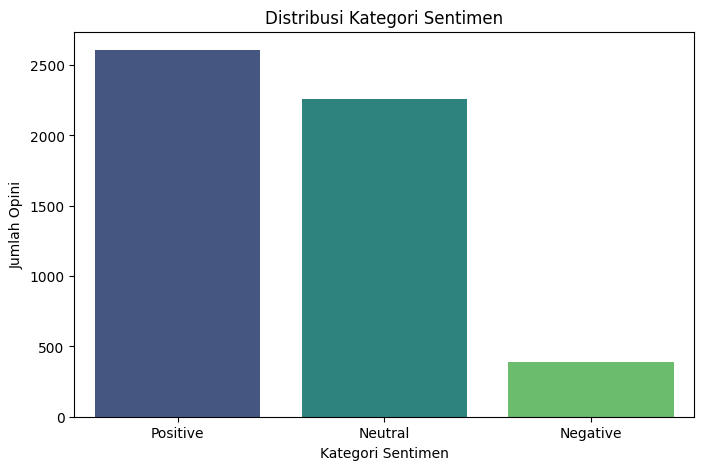


Distribusi Aspek:
Aspek
lainnya                              2119
kualitas pelayanan medis dan staf    1886
fasilitas dan infrastruktur           903
waktu tunggu                          261
biaya layanan                          86
Name: count, dtype: int64


/tmp/ipykernel_1887/3331647713.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspek_distribution.index, y=aspek_distribution.values, palette='magma')


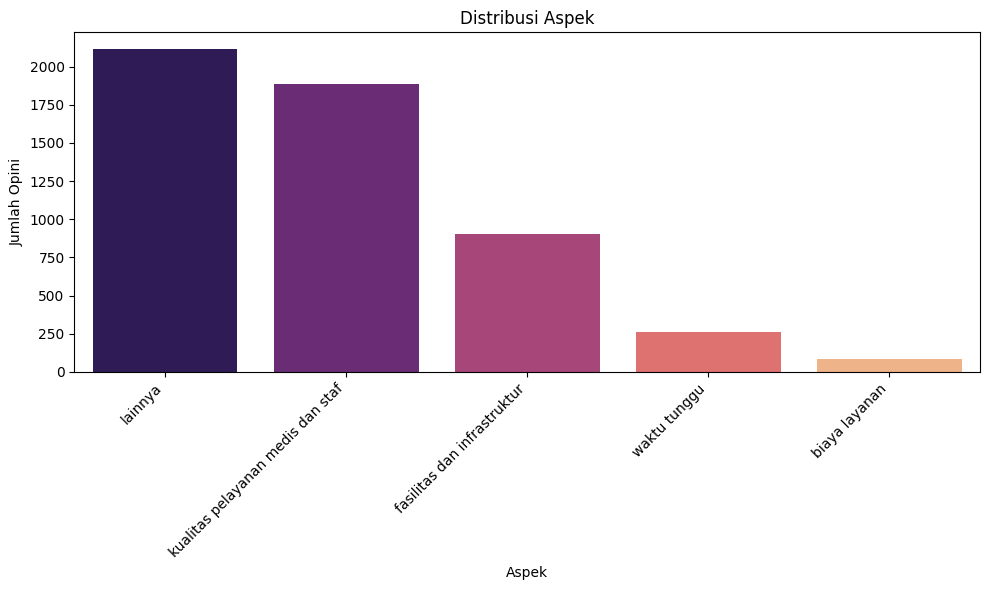

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Load the DataFrame if it's not already in memory (e.g., if running cells out of order)
if 'df_aspect_labeling' not in locals():
    PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
    try:
        df_aspect_labeling = pd.read_excel(os.path.join(PREPROCESSED_DATA_DIR, 'dataset_hasil_labelling_aspek.xlsx'))
        print("Loaded df_aspect_labeling from drive for distribution analysis.")
    except FileNotFoundError:
        print("Error: 'dataset_hasil_labelling_aspek.xlsx' not found. Please ensure previous steps ran successfully.")
        raise # Re-raise the exception to stop execution if file is not found

print("\nDistribusi Sentimen:")
sentiment_distribution = df_aspect_labeling['Vader_Sentiment_Category'].value_counts()
print(sentiment_distribution)

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribusi Kategori Sentimen')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Jumlah Opini')
plt.show()

print("\nDistribusi Aspek:")
aspek_distribution = df_aspect_labeling['Aspek'].value_counts()
print(aspek_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x=aspek_distribution.index, y=aspek_distribution.values, palette='magma')
plt.title('Distribusi Aspek')
plt.xlabel('Aspek')
plt.ylabel('Jumlah Opini')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
import pandas as pd

# Ensure df_aspect_labeling is loaded if not already in memory
if 'df_aspect_labeling' not in locals():
    PREPROCESSED_DATA_DIR = os.path.join(BASE_DRIVE_PATH, 'preprocessed_data')
    try:
        df_aspect_labeling = pd.read_excel(os.path.join(PREPROCESSED_DATA_DIR, 'dataset_hasil_labelling_aspek.xlsx'))
        print("Loaded df_aspect_labeling from drive for combined distribution analysis.")
    except FileNotFoundError:
        print("Error: 'dataset_hasil_labelling_aspek.xlsx' not found. Please ensure previous steps ran successfully.")
        raise # Re-raise the exception to stop execution if file is not found

# Create a contingency table (cross-tabulation) of 'Aspek' and 'Vader_Sentiment_Category'
combined_distribution = pd.crosstab(
    df_aspect_labeling['Aspek'],
    df_aspect_labeling['Vader_Sentiment_Category']
)

print("\nDistribusi Gabungan Aspek dan Sentimen:")
display(combined_distribution)


Distribusi Gabungan Aspek dan Sentimen:


Vader_Sentiment_Category,Negative,Neutral,Positive
Aspek,,,
biaya layanan,5,58,23
fasilitas dan infrastruktur,56,229,618
kualitas pelayanan medis dan staf,46,567,1273
lainnya,275,1201,643
waktu tunggu,7,204,50
